# Vehicle Health Telemetry EDA
Professional notebook for executive reporting, diagnostics, and export-ready analysis.

This notebook follows the requested order: executive summary, overview, data quality, missing values, duplicates, target analysis, sensor analysis, outliers, correlation, feature vs target, time series, rolling statistics, statistical tests, key findings, and exports.


In [6]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

df = pd.read_csv('Cleaned-Vehicle-Health-Telemetry-Dataset.csv')
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

if 'Fault_Type' in df.columns:
    df['is_fault'] = np.where(df['Fault_Type'].fillna('Normal').astype(str).str.lower().eq('normal'), 0, 1)
elif 'Fault_Label' in df.columns:
    fault_label_numeric = pd.to_numeric(df['Fault_Label'], errors='coerce')
    threshold = fault_label_numeric.median(skipna=True)
    df['is_fault'] = np.where(fault_label_numeric > threshold, 1, 0)
else:
    df['is_fault'] = 0

target = 'is_fault'
feature_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in {'Fault_Label', target}]
main_sensors = [c for c in ['Coolant_Temp', 'Engine_RPM', 'Oil_Pressure', 'Battery_Voltage', 'Vibration_Z', 'Fuel_Rate'] if c in df.columns]
time_col = 'Timestamp' if 'Timestamp' in df.columns else None
target_labels = ['Normal', 'Fault']
target_colors = ['#2a9d8f', '#e76f51']


## Notebook Map
1. Executive Summary
2. Data Dictionary
3. Dataset Overview
4. Data Quality Report
5. Missing Values Analysis
6. Duplicate Analysis
7. Target Distribution
8. Descriptive Statistics
9. Numerical Feature Distribution
10. Outlier Analysis
11. Correlation Analysis
12. Feature vs Target
13. Time Series Analysis
14. Rolling Statistics
15. Distribution Comparison
16. Statistical Tests
17. Key Findings
18. Export Clean Dataset


In [7]:
pretty = {
    'Coolant_Temp': 'Temperature',
    'Engine_RPM': 'RPM',
    'Oil_Pressure': 'Oil Pressure',
    'Battery_Voltage': 'Battery Voltage',
    'Vibration_Z': 'Vibration',
    'Fuel_Rate': 'Fuel Rate',
}

memory_usage_mb = df.memory_usage(deep=True).sum() / 1024 ** 2
fault_rate = df[target].mean() * 100
fault_counts = df[target].value_counts().sort_index()
top_spread = df[feature_cols].std().sort_values(ascending=False).head(3)



In [8]:
if 'memory_usage_mb' not in globals():
	memory_usage_mb = df.memory_usage(deep=True).sum() / 1024 ** 2

if 'fault_counts' not in globals():
	fault_counts = df[target].value_counts().sort_index()

summary_df = pd.DataFrame({
	'Metric': [
		'Dataset Shape',
		'Number of Features',
		'Number of Numeric Features',
		'Data Types',
		'Memory Usage',
		'Target Distribution (is_fault)'
	],
	'Value': [
		str(df.shape),
		df.shape[1],
		len(feature_cols),
		df.dtypes.astype(str).value_counts().to_dict(),
		f'{memory_usage_mb:.2f} MB',
		{'Normal': int(fault_counts.get(0, 0)), 'Fault': int(fault_counts.get(1, 0))}
	]
})
display(summary_df)
if 'fault_rate' not in globals():
	fault_rate = df[target].mean() * 100

if 'top_spread' not in globals():
	top_spread = df[feature_cols].std().sort_values(ascending=False).head(3)

display(Markdown('### Top 3 Notes\n' + '\n'.join([
	f'- Faults account for {fault_rate:.2f}% of observations.',
	f'- {top_spread.index[0]} shows the widest spread among numeric features.',
	f'- {top_spread.index[1]} and {top_spread.index[2]} follow as the next most variable signals.'
])))

,Metric,Value
0,Dataset Shape,"(604800, 18)"
1,Number of Features,18
2,Number of Numeric Features,14
3,Data Types,"{'float64': 15, 'datetime64[us]': 1, 'str': 1,..."
4,Memory Usage,110.41 MB
5,Target Distribution (is_fault),"{'Normal': 571783, 'Fault': 33017}"


### Top 3 Notes
- Faults account for 5.46% of observations.
- Engine_RPM shows the widest spread among numeric features.
- Coolant_Temp and Engine_Load follow as the next most variable signals.

In [9]:
data_dictionary = pd.DataFrame([
    {'Feature': 'Timestamp', 'Description': 'Measurement time', 'Unit': 'datetime'},
    {'Feature': 'Engine_RPM', 'Description': 'Engine rotational speed', 'Unit': 'rpm'},
    {'Feature': 'Vehicle_Speed', 'Description': 'Vehicle road speed', 'Unit': 'km/h'},
    {'Feature': 'Coolant_Temp', 'Description': 'Engine coolant temperature', 'Unit': '°C'},
    {'Feature': 'Oil_Pressure', 'Description': 'Engine oil pressure', 'Unit': 'bar'},
    {'Feature': 'Vibration_Z', 'Description': 'Measured vibration level on the Z axis', 'Unit': 'mm/s'},
    {'Feature': 'Engine_Load', 'Description': 'Engine load percentage', 'Unit': '%'},
    {'Feature': 'Fuel_Rate', 'Description': 'Fuel consumption rate', 'Unit': 'L/h'},
    {'Feature': 'Intake_Air_Temp', 'Description': 'Air intake temperature', 'Unit': '°C'},
    {'Feature': 'Battery_Voltage', 'Description': 'Vehicle battery voltage', 'Unit': 'V'},
    {'Feature': 'Throttle_Position', 'Description': 'Throttle opening percentage', 'Unit': '%'},
    {'Feature': 'Ambient_Temp', 'Description': 'Ambient temperature', 'Unit': '°C'},
    {'Feature': 'Brake_Pressure', 'Description': 'Brake system pressure', 'Unit': 'bar'},
    {'Feature': 'Acceleration_X', 'Description': 'Longitudinal acceleration', 'Unit': 'm/s²'},
    {'Feature': 'Acceleration_Y', 'Description': 'Lateral acceleration', 'Unit': 'm/s²'},
    {'Feature': 'Fault_Label', 'Description': 'Original fault score / label', 'Unit': 'score'},
    {'Feature': 'Fault_Type', 'Description': 'Fault class name', 'Unit': 'category'},
    {'Feature': 'is_fault', 'Description': 'Binary target used for analysis', 'Unit': '0/1'}
])
display(data_dictionary)

,Feature,Description,Unit
0,Timestamp,Measurement time,datetime
1,Engine_RPM,Engine rotational speed,rpm
2,Vehicle_Speed,Vehicle road speed,km/h
3,Coolant_Temp,Engine coolant temperature,°C
4,Oil_Pressure,Engine oil pressure,bar
5,Vibration_Z,Measured vibration level on the Z axis,mm/s
6,Engine_Load,Engine load percentage,%
7,Fuel_Rate,Fuel consumption rate,L/h
8,Intake_Air_Temp,Air intake temperature,°C
9,Battery_Voltage,Vehicle battery voltage,V


In [10]:
display(df.head())
display(df.sample(5, random_state=42))
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue())
display(df.describe().T)

,Timestamp,Engine_RPM,Vehicle_Speed,Coolant_Temp,Oil_Pressure,Vibration_Z,Engine_Load,Fuel_Rate,Intake_Air_Temp,Battery_Voltage,Throttle_Position,Ambient_Temp,Brake_Pressure,Acceleration_X,Acceleration_Y,Fault_Label,Fault_Type,is_fault
0,2026-06-01 00:00:00,0.0000,0.0000,21.2597,1.6610,0.0134,0.0000,0.0000,21.9331,12.4885,0.0000,21.4467,0.5000,0.0000,0.0000,0.0000,Normal,0
1,2026-06-01 00:00:01,0.0000,0.0000,21.2597,1.6539,0.0122,0.0000,0.0000,21.7023,12.4883,0.0000,21.4086,0.5000,0.0000,0.0000,0.0000,Normal,0
2,2026-06-01 00:00:02,0.0000,0.0000,21.3052,1.4533,0.0132,0.0000,0.0000,21.7941,12.4909,0.0000,21.4253,0.5000,0.0000,0.0000,0.0000,Normal,0
3,2026-06-01 00:00:03,0.0000,0.0000,21.3841,1.3843,0.0135,0.0000,0.0000,21.5087,12.4977,0.0000,21.4912,0.5000,0.0000,0.0000,0.0000,Normal,0
4,2026-06-01 00:00:04,0.0000,0.0000,21.3877,1.8656,0.0108,0.0000,0.0000,21.7857,12.4969,0.0000,21.4384,0.5000,0.0000,0.0000,0.0000,Normal,0


,Timestamp,Engine_RPM,Vehicle_Speed,Coolant_Temp,Oil_Pressure,Vibration_Z,Engine_Load,Fuel_Rate,Intake_Air_Temp,Battery_Voltage,Throttle_Position,Ambient_Temp,Brake_Pressure,Acceleration_X,Acceleration_Y,Fault_Label,Fault_Type,is_fault
174330,2026-06-03 00:25:30,0.0000,0.0000,20.9463,2.2775,0.0117,0.0000,0.0000,20.5918,13.6413,0.0000,20.4687,0.5000,-0.0000,0.0000,0.0000,Normal,0
12668,2026-06-01 03:31:08,0.0000,0.0000,18.1517,1.8236,0.0076,0.0000,0.0000,17.6426,12.2437,0.0000,18.0254,0.5000,0.0000,0.0000,0.0000,Normal,0
445003,2026-06-06 03:36:43,0.0000,0.0000,17.7841,2.2596,0.0132,0.0000,0.0000,17.7791,13.3896,0.0000,18.0084,0.5000,-0.0000,-0.0000,0.0000,Normal,0
156156,2026-06-02 19:22:36,841.6294,0.6009,91.4872,16.5168,0.1581,15.6486,2.5658,33.3170,13.9473,13.2566,30.4275,0.7460,-0.0499,0.0009,0.0000,Normal,0
100969,2026-06-02 04:02:49,0.0000,0.0000,17.9795,2.3348,0.0072,0.0000,0.0000,17.8960,13.3920,0.0000,17.9635,0.5000,0.0000,-0.0000,0.0000,Normal,0


<class 'pandas.DataFrame'>
RangeIndex: 604800 entries, 0 to 604799
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Timestamp          604800 non-null  datetime64[us]
 1   Engine_RPM         604800 non-null  float64       
 2   Vehicle_Speed      604800 non-null  float64       
 3   Coolant_Temp       604800 non-null  float64       
 4   Oil_Pressure       604800 non-null  float64       
 5   Vibration_Z        604800 non-null  float64       
 6   Engine_Load        604800 non-null  float64       
 7   Fuel_Rate          604800 non-null  float64       
 8   Intake_Air_Temp    604800 non-null  float64       
 9   Battery_Voltage    604800 non-null  float64       
 10  Throttle_Position  604800 non-null  float64       
 11  Ambient_Temp       604800 non-null  float64       
 12  Brake_Pressure     604800 non-null  float64       
 13  Acceleration_X     604800 non-null  float64       
 14 

,count,mean,min,25%,50%,75%,max,std
Timestamp,604800,2026-06-04 11:59:59.500000,2026-06-01 00:00:00,2026-06-02 17:59:59.750000,2026-06-04 11:59:59.500000,2026-06-06 05:59:59.250000,2026-06-07 23:59:59,NaN
Engine_RPM,"604,800.0000",286.1556,0.0000,0.0000,0.0000,768.7663,"2,830.9106",413.1664
Vehicle_Speed,"604,800.0000",0.8314,0.0000,0.0000,0.0000,0.0000,94.1034,6.3667
Coolant_Temp,"604,800.0000",47.5348,10.2754,20.3430,33.0294,82.9414,129.2882,31.1512
Oil_Pressure,"604,800.0000",6.7210,0.0000,2.2924,2.7903,15.0687,56.7953,6.9158
Vibration_Z,"604,800.0000",0.1190,0.0035,0.0095,0.0112,0.1378,1.6914,0.2125
Engine_Load,"604,800.0000",5.5904,0.0000,0.0000,0.0000,13.0051,70.6561,8.7047
Fuel_Rate,"604,800.0000",0.8778,0.0000,0.0000,0.0000,2.2715,9.2531,1.2754
Intake_Air_Temp,"604,800.0000",26.8199,16.6354,20.3616,27.1641,32.8086,45.2644,6.2605
Battery_Voltage,"604,800.0000",13.6597,11.9127,13.5028,13.8119,13.9379,14.1732,0.4100


In [11]:
missing_values = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())
duplicate_timestamp = int(df.duplicated(subset=[time_col]).sum()) if time_col else 'N/A'
constant_columns = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
near_constant_columns = [c for c in df.columns if (df[c].nunique(dropna=False) / len(df)) <= 0.01]
infinite_values = int(np.isinf(df.select_dtypes(include=np.number)).sum().sum())
quality_df = pd.DataFrame([
    ['Missing Values', missing_values],
    ['Duplicate Rows', duplicate_rows],
    ['Duplicate Timestamp', duplicate_timestamp],
    ['Constant Columns', len(constant_columns)],
    ['Near Constant Columns', len(near_constant_columns)],
    ['Infinite Values', infinite_values],
    ['Memory Usage', f'{memory_usage_mb:.2f} MB'],
], columns=['Metric', 'Value'])
display(quality_df)
display(Markdown('No missing values were detected.' if missing_values == 0 else f'{missing_values} missing values were detected.'))


,Metric,Value
0,Missing Values,0
1,Duplicate Rows,0
2,Duplicate Timestamp,0
3,Constant Columns,0
4,Near Constant Columns,2
5,Infinite Values,0
6,Memory Usage,110.41 MB


No missing values were detected.

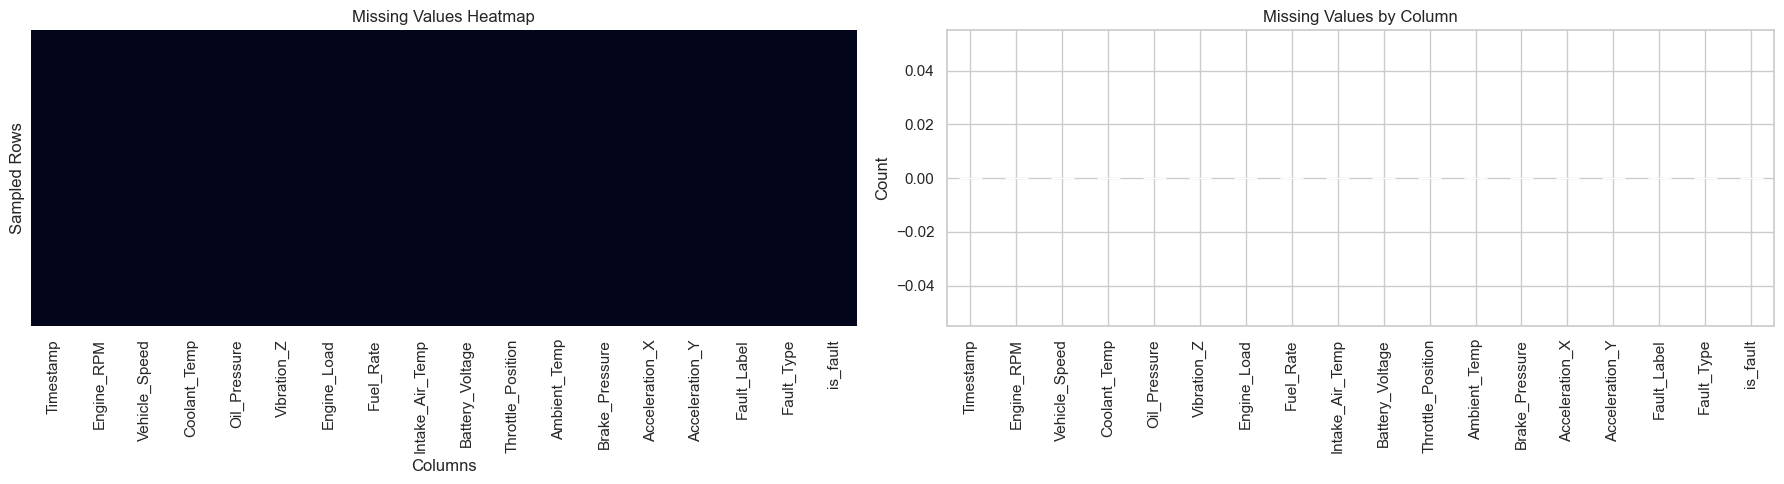

No missing values were detected.

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.heatmap(df.isna().iloc[:min(200, len(df))], cbar=False, yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Values Heatmap')
axes[0].set_xlabel('Columns')
axes[0].set_ylabel('Sampled Rows')
df.isna().sum().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#264653')
axes[1].set_title('Missing Values by Column')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()
display(Markdown('No missing values were detected.' if missing_values == 0 else 'Missing values are present in the dataset.'))


In [13]:
if 'duplicate_rows' not in globals():
	duplicate_rows = int(df.duplicated().sum())

if 'duplicate_timestamp' not in globals():
	duplicate_timestamp = int(df.duplicated(subset=[time_col]).sum()) if 'time_col' in globals() and time_col else 'N/A'

dup_report = pd.DataFrame(
	[
		['Number of duplicate rows', duplicate_rows],
		['Duplicated timestamps', duplicate_timestamp]
	],
	columns=['Metric', 'Value']
)
display(dup_report)


,Metric,Value
0,Number of duplicate rows,0
1,Duplicated timestamps,0


C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\1964440489.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\1964440489.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)


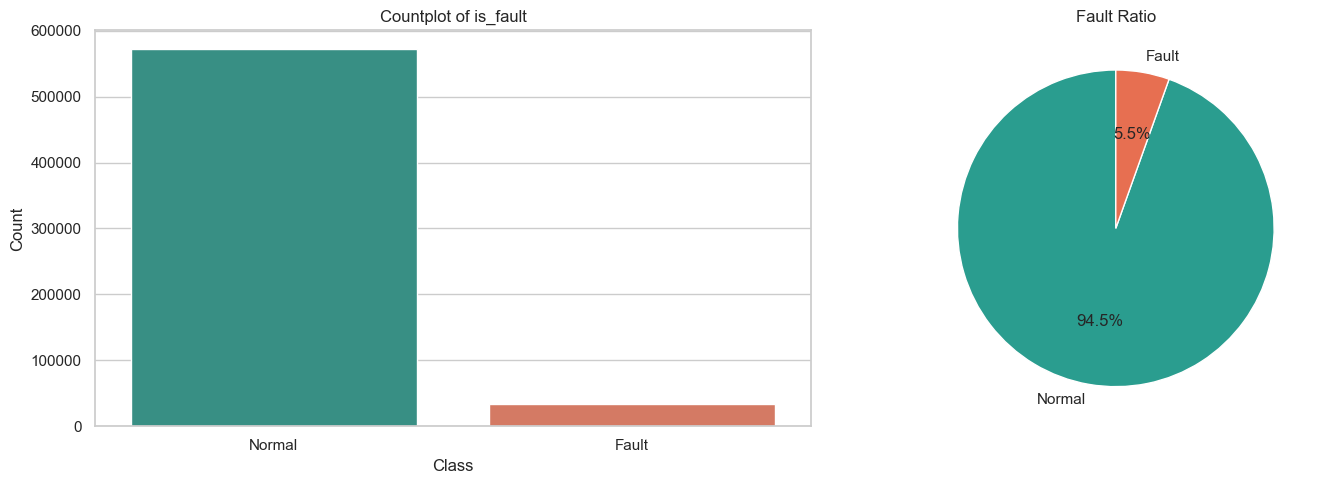

Faults account for 5.46% of observations, so the dataset is highly imbalanced toward normal behavior.

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, x=target, palette=target_colors, ax=axes[0])
axes[0].set_xticklabels(target_labels)
axes[0].set_title('Countplot of is_fault')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[1].pie(fault_counts.values, labels=target_labels, autopct='%1.1f%%', colors=target_colors, startangle=90)
axes[1].set_title('Fault Ratio')
plt.tight_layout()
plt.show()
display(Markdown(f'Faults account for {fault_rate:.2f}% of observations, so the dataset is highly imbalanced toward normal behavior.'))



In [15]:
statistical_summary = pd.DataFrame({
    'Mean': df[feature_cols].mean(),
    'Median': df[feature_cols].median(),
    'Std': df[feature_cols].std(),
    'Min': df[feature_cols].min(),
    'Max': df[feature_cols].max(),
    'Skewness': df[feature_cols].skew(),
    'Kurtosis': df[feature_cols].kurtosis()
}).round(4)
display(statistical_summary)

,Mean,Median,Std,Min,Max,Skewness,Kurtosis
Engine_RPM,286.1556,0.0000,413.1664,0.0000,"2,830.9106",1.2257,1.6971
Vehicle_Speed,0.8314,0.0000,6.3667,0.0000,94.1034,9.3056,94.6389
Coolant_Temp,47.5348,33.0294,31.1512,10.2754,129.2882,0.5732,-1.4573
Oil_Pressure,6.7210,2.7903,6.9158,0.0000,56.7953,1.6227,3.9881
Vibration_Z,0.1190,0.0112,0.2125,0.0035,1.6914,2.3661,4.9105
Engine_Load,5.5904,0.0000,8.7047,0.0000,70.6561,1.7379,3.6916
Fuel_Rate,0.8778,0.0000,1.2754,0.0000,9.2531,1.2572,1.7504
Intake_Air_Temp,26.8199,27.1641,6.2605,16.6354,45.2644,-0.0460,-1.4943
Battery_Voltage,13.6597,13.8119,0.4100,11.9127,14.1732,-2.1763,5.1576
Throttle_Position,5.0309,0.0000,7.8330,0.0000,64.3679,1.7345,3.6651


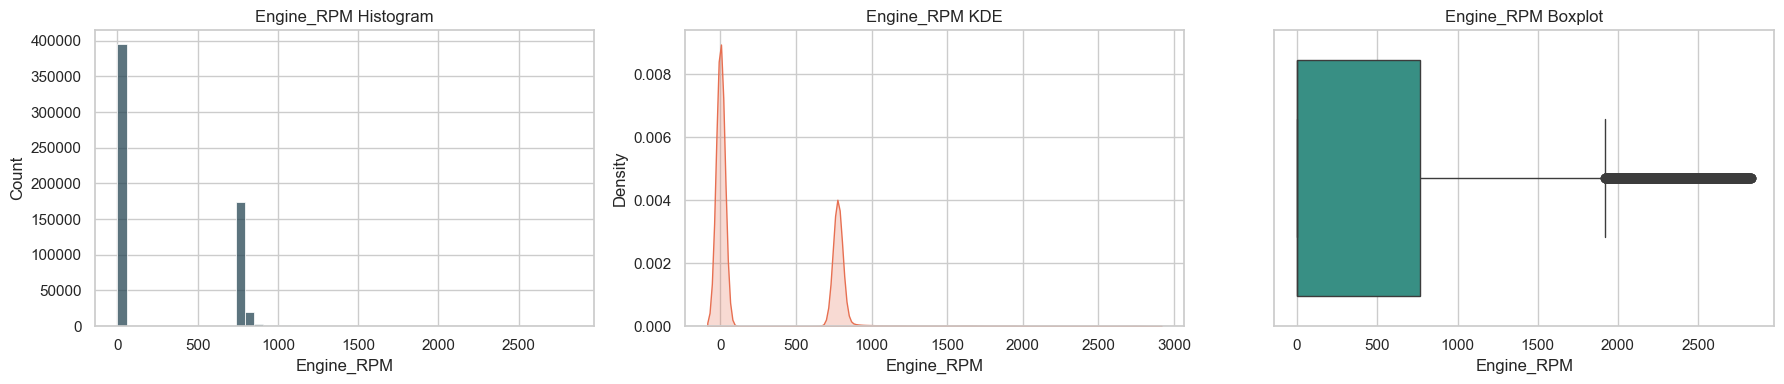

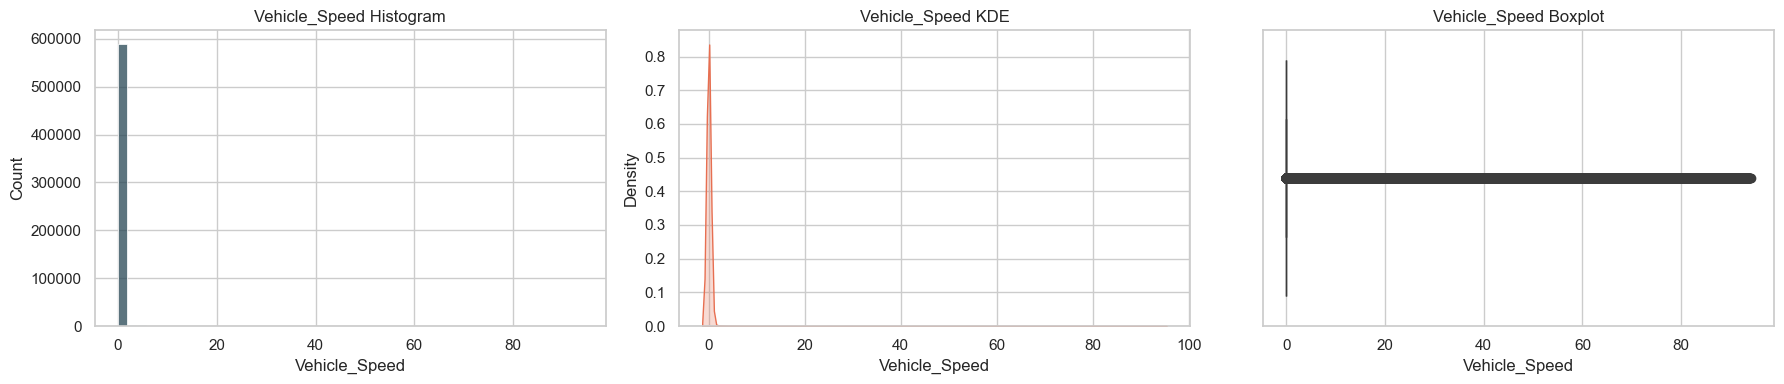

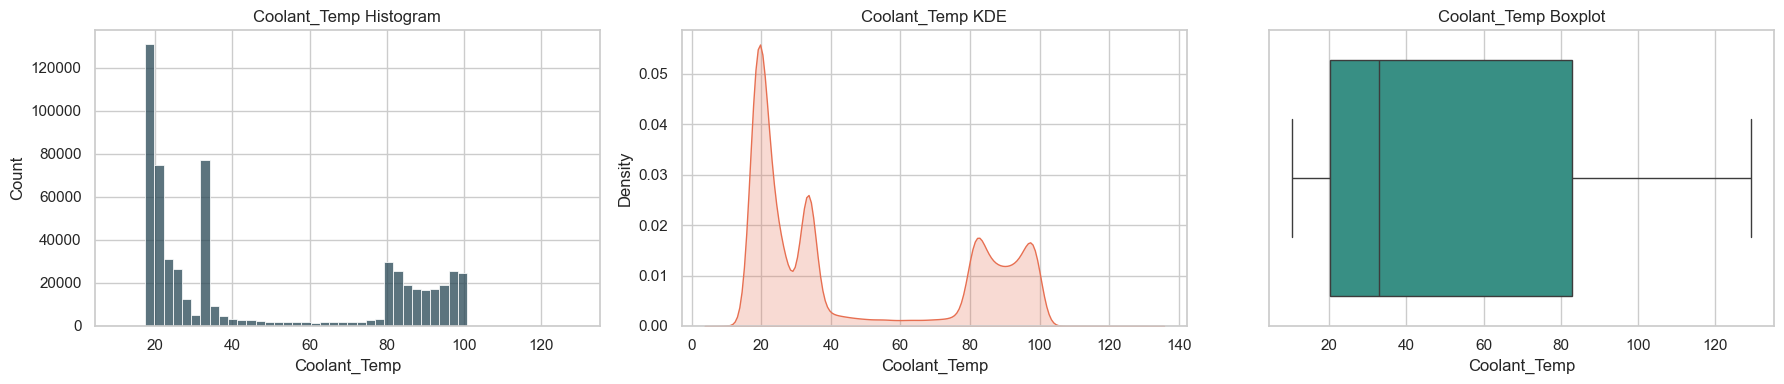

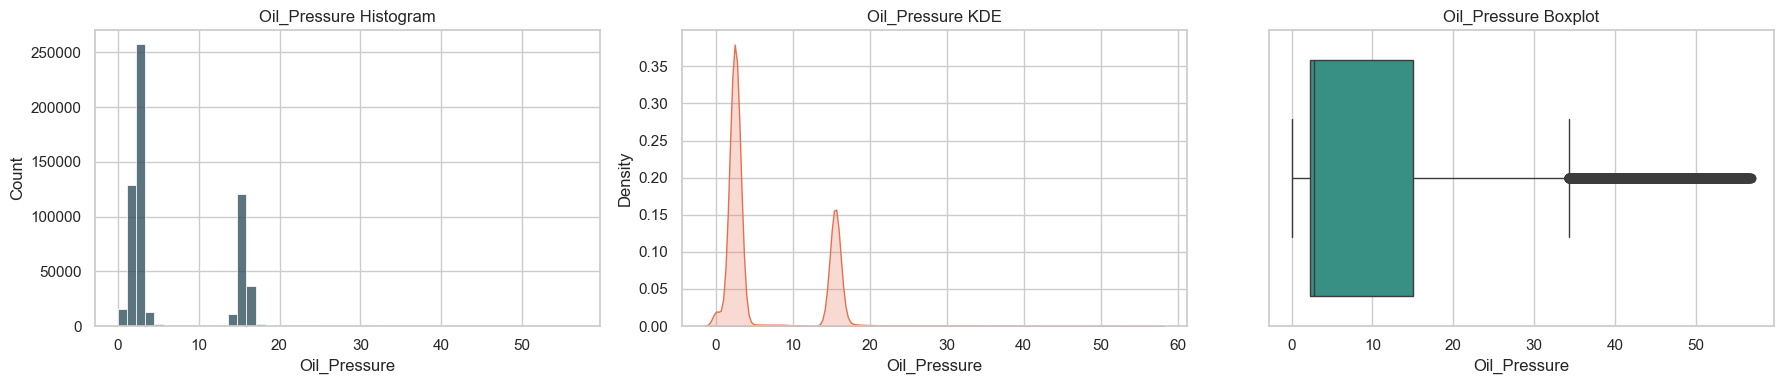

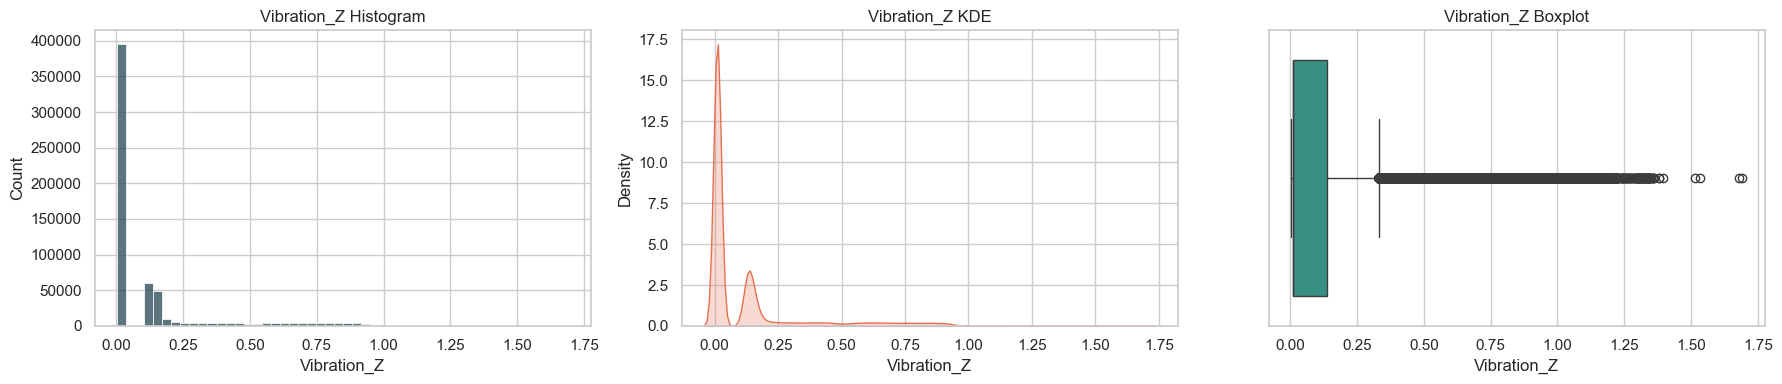

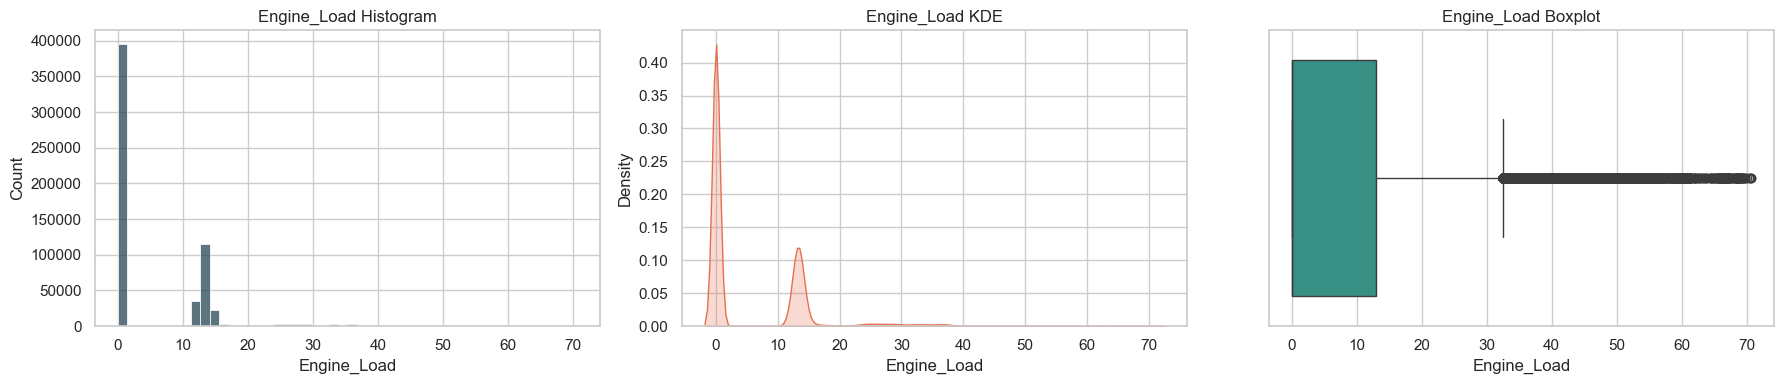

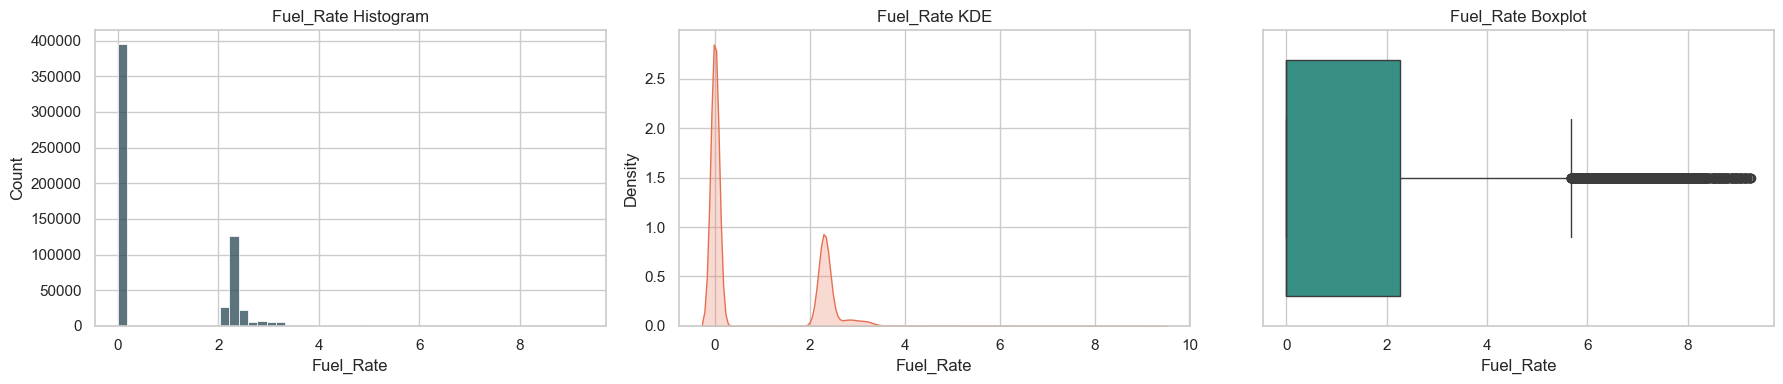

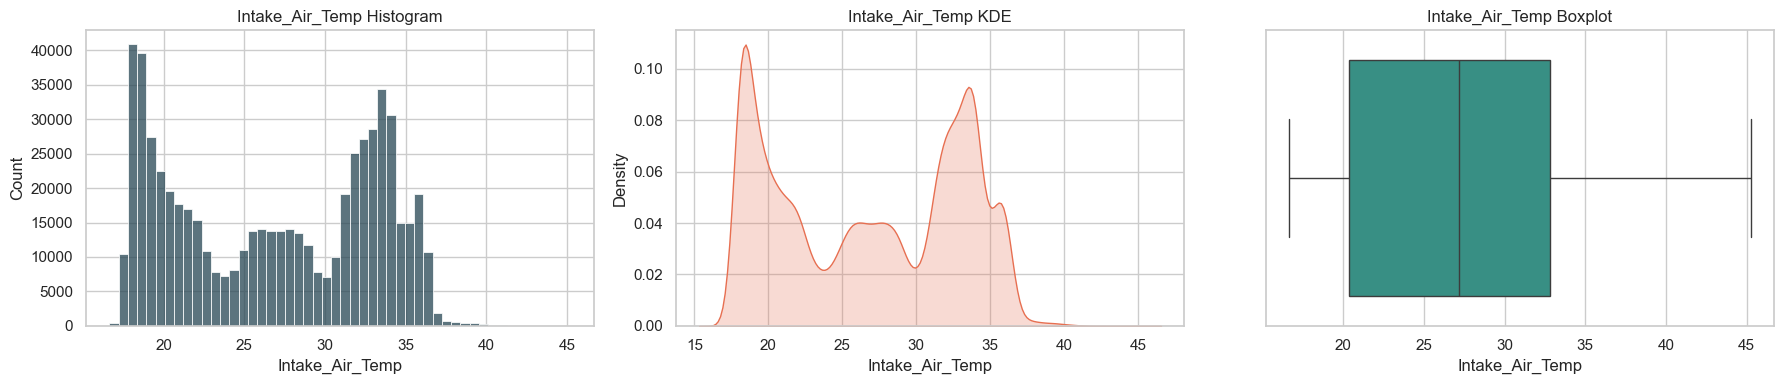

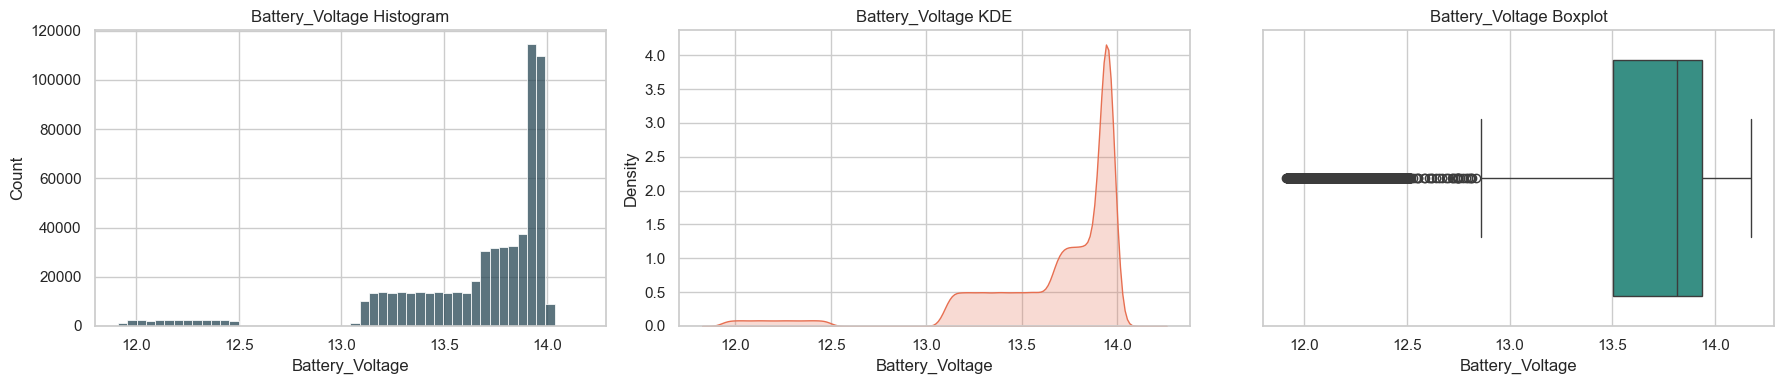

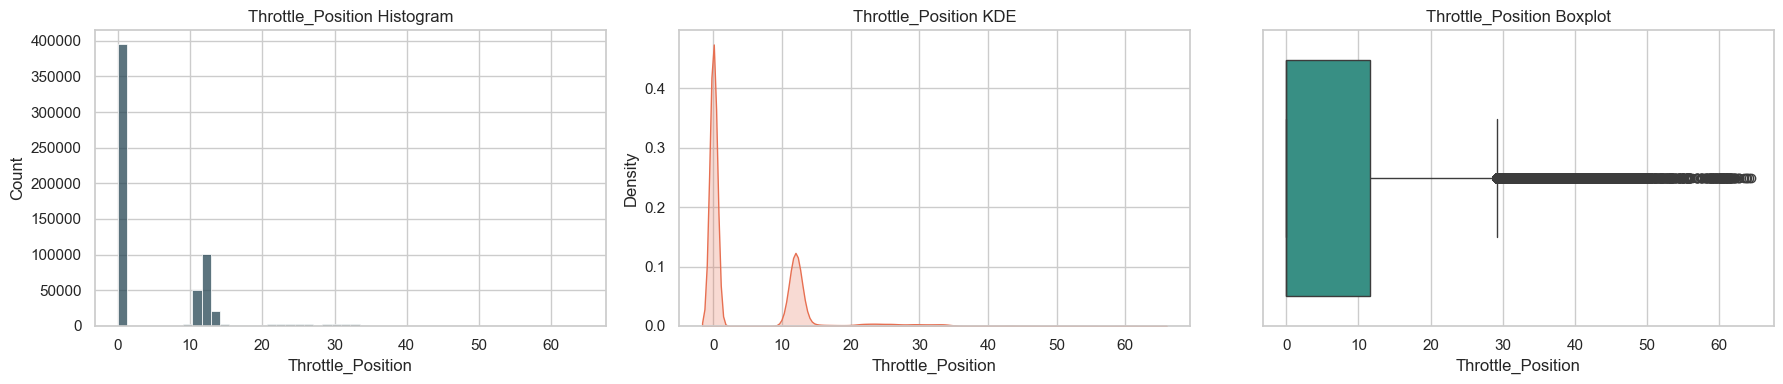

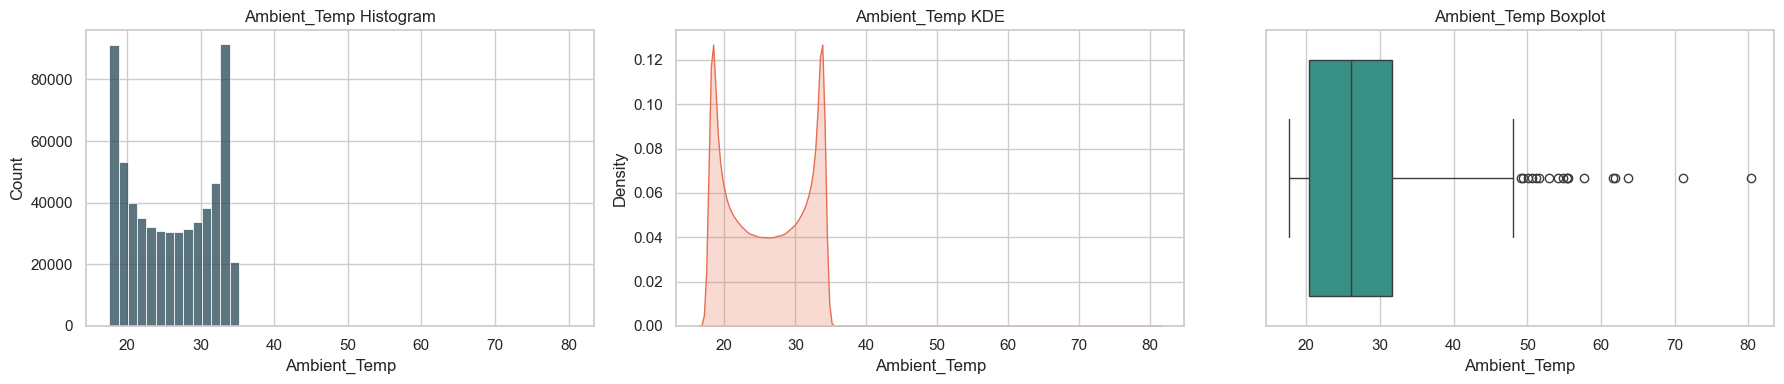

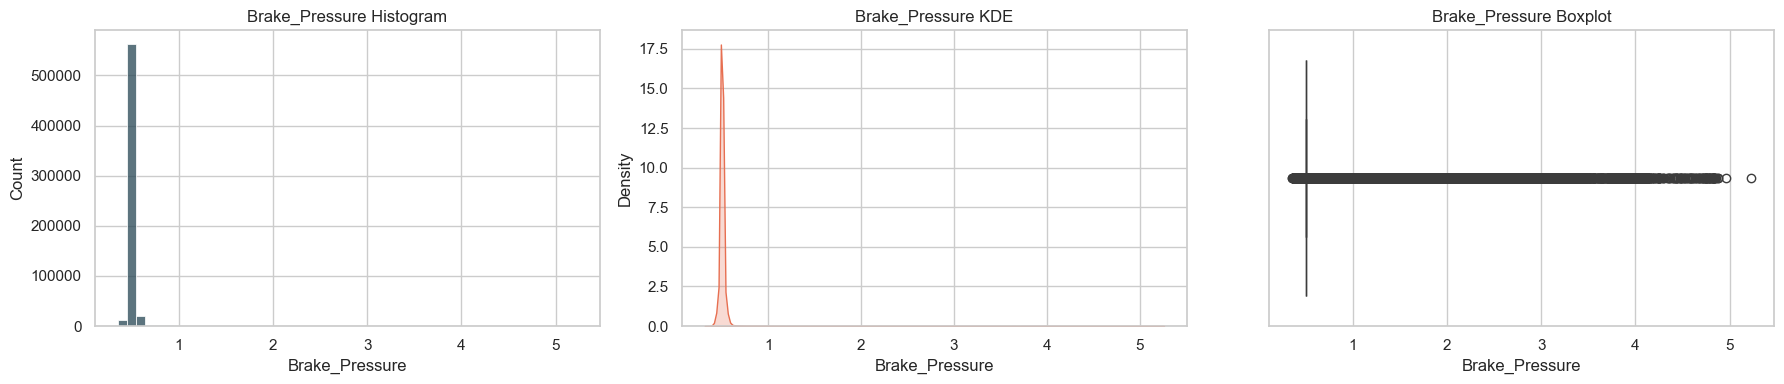

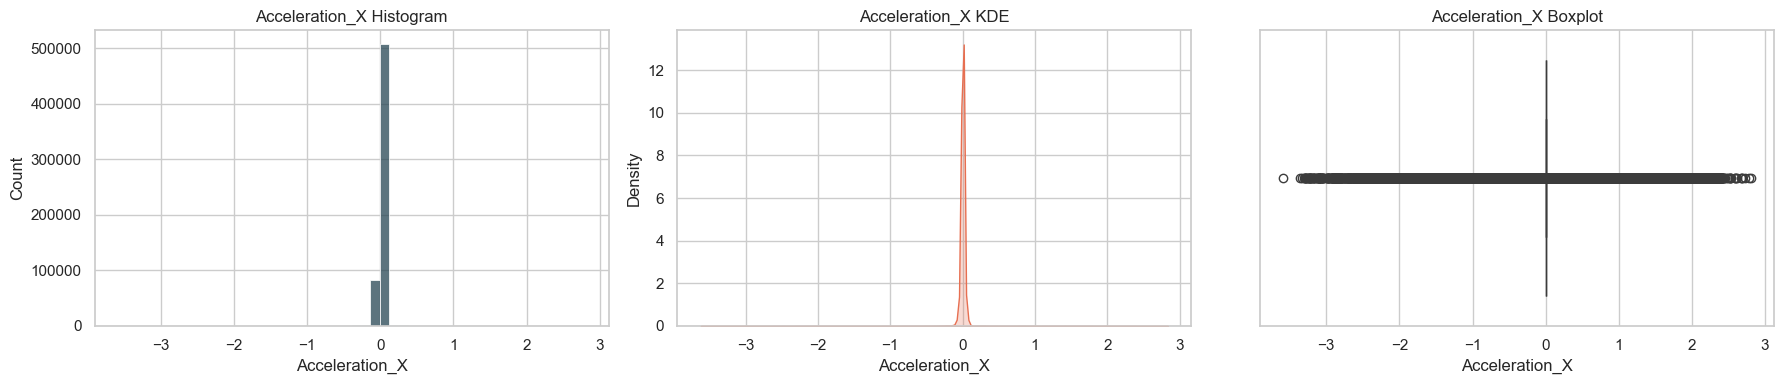

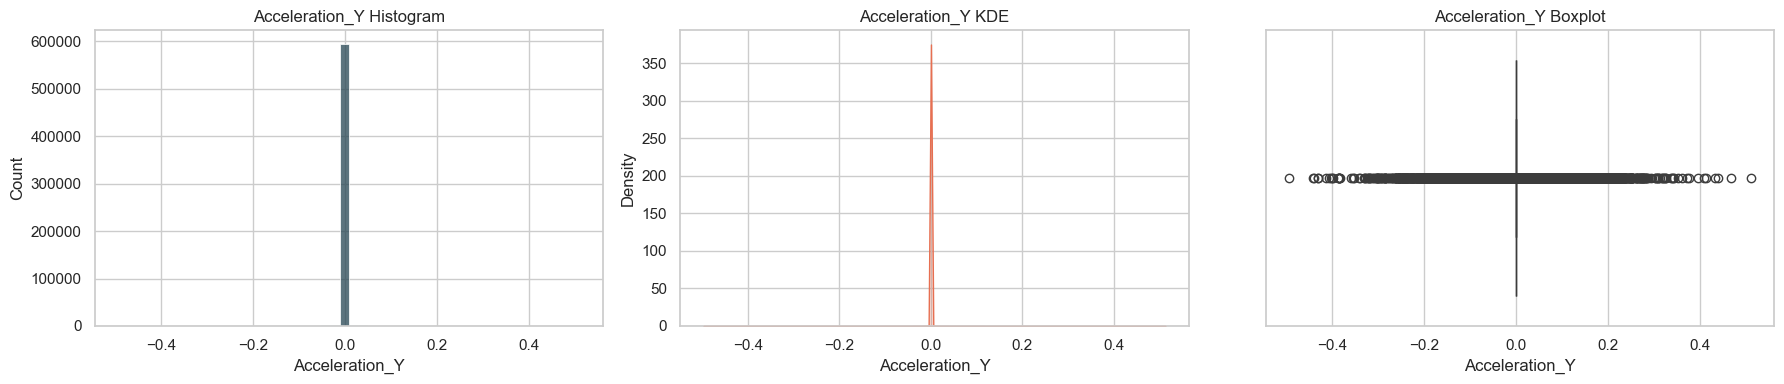

In [16]:
for col in feature_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(df[col].dropna(), bins=50, color='#264653', ax=axes[0])
    axes[0].set_title(f'{col} Histogram')
    sns.kdeplot(df[col].dropna(), fill=True, color='#e76f51', ax=axes[1])
    axes[1].set_title(f'{col} KDE')
    sns.boxplot(x=df[col], color='#2a9d8f', ax=axes[2])
    axes[2].set_title(f'{col} Boxplot')
    plt.tight_layout()
    plt.show()




In [17]:
outlier_rows = []
for col in feature_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((df[col] < lower_bound) | (df[col] > upper_bound)).sum())
    outlier_rows.append([col, outlier_count, round(outlier_count / len(df) * 100, 4)])
outlier_df = pd.DataFrame(outlier_rows, columns=['Feature', 'Number of Outliers', 'Percentage']).sort_values('Percentage', ascending=False)
display(outlier_df)



,Feature,Number of Outliers,Percentage
12,Acceleration_X,256326,42.3819
13,Acceleration_Y,244623,40.4469
11,Brake_Pressure,213431,35.2895
1,Vehicle_Speed,150478,24.8806
4,Vibration_Z,72543,11.9945
8,Battery_Voltage,28567,4.7234
9,Throttle_Position,12249,2.0253
5,Engine_Load,12065,1.9949
3,Oil_Pressure,3537,0.5848
6,Fuel_Rate,3209,0.5306


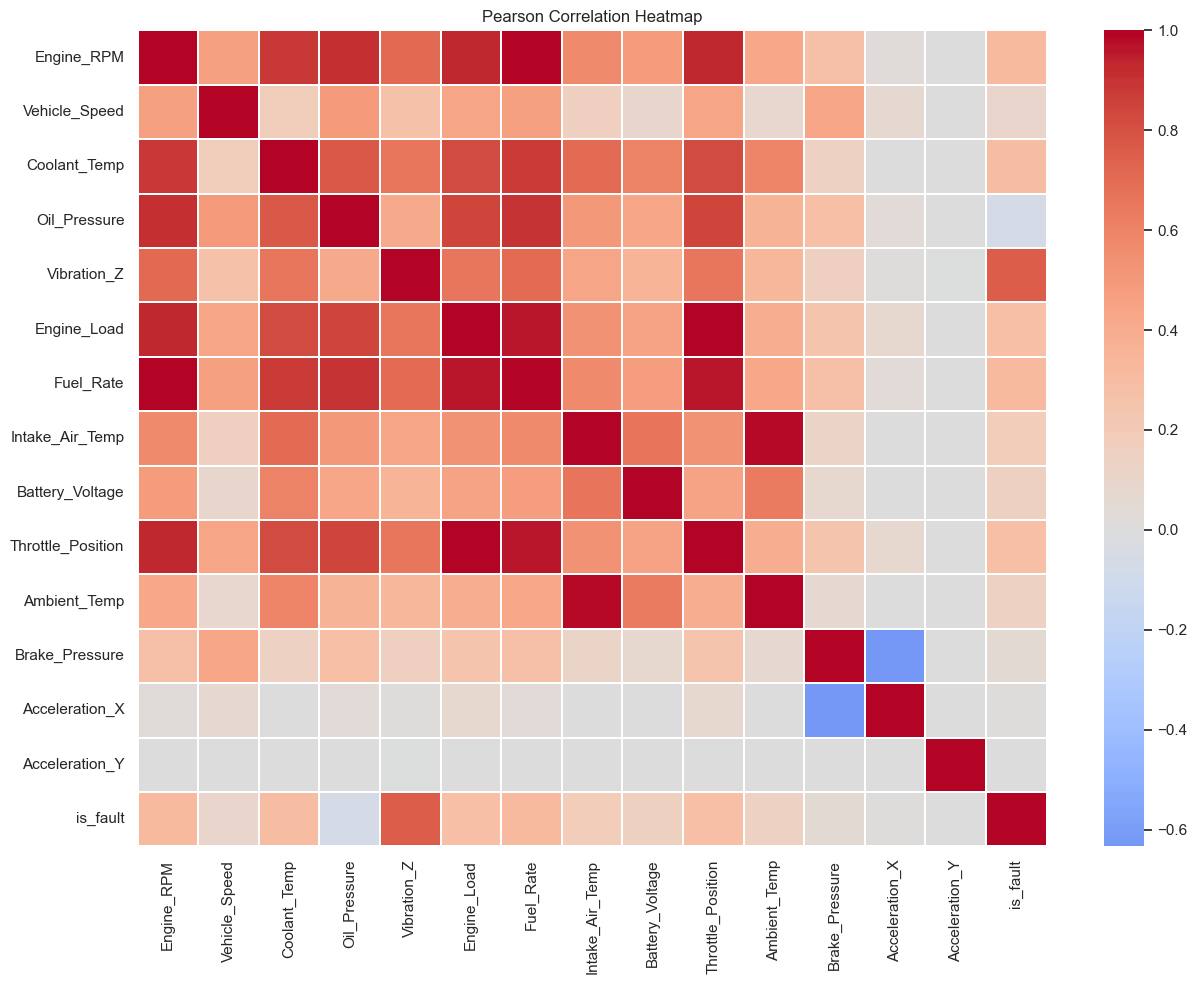

### Top 10 Positive Correlations

,Feature 1,Feature 2,Correlation
84,Engine_Load,Throttle_Position,0.9992
6,Engine_RPM,Fuel_Rate,0.9943
115,Intake_Air_Temp,Ambient_Temp,0.9832
81,Engine_Load,Fuel_Rate,0.9618
99,Fuel_Rate,Throttle_Position,0.9614
5,Engine_RPM,Engine_Load,0.9304
9,Engine_RPM,Throttle_Position,0.9301
3,Engine_RPM,Oil_Pressure,0.9079
51,Oil_Pressure,Fuel_Rate,0.9035
2,Engine_RPM,Coolant_Temp,0.8842


### Top 10 Negative Correlations

,Feature 1,Feature 2,Correlation
177,Brake_Pressure,Acceleration_X,-0.6339
59,Oil_Pressure,is_fault,-0.0621
73,Vibration_Z,Acceleration_Y,-0.0046
209,Acceleration_Y,is_fault,-0.0015
193,Acceleration_X,Acceleration_Y,-0.0007
133,Battery_Voltage,Acceleration_Y,-0.0007
148,Throttle_Position,Acceleration_Y,0.0002
88,Engine_Load,Acceleration_Y,0.0003
43,Coolant_Temp,Acceleration_Y,0.0005
42,Coolant_Temp,Acceleration_X,0.0008


In [18]:
corr_features = feature_cols + [target]
corr_matrix = df[corr_features].corr(method='pearson')
plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
display(Markdown('### Top 10 Positive Correlations'))
display(corr_pairs.sort_values('Correlation', ascending=False).head(10))
display(Markdown('### Top 10 Negative Correlations'))
display(corr_pairs.sort_values('Correlation', ascending=True).head(10))


C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

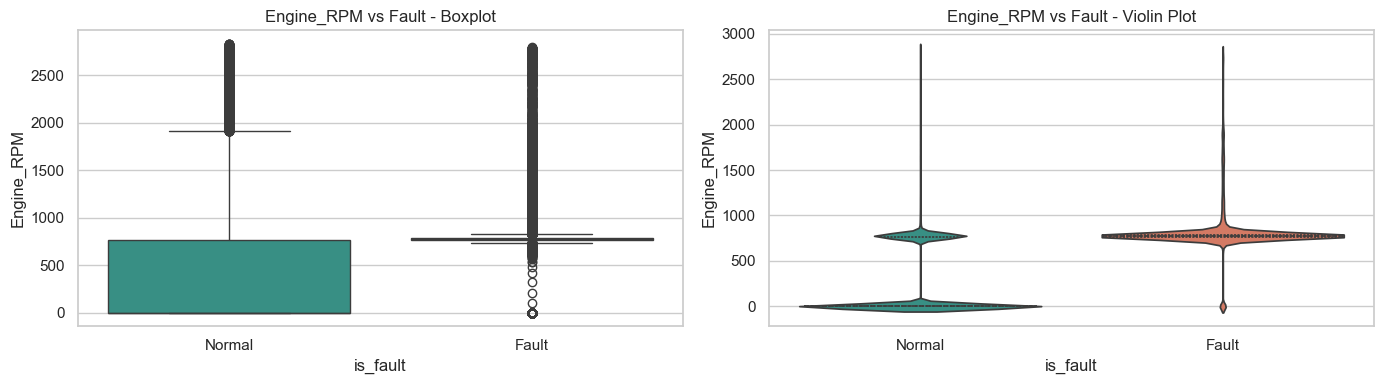

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

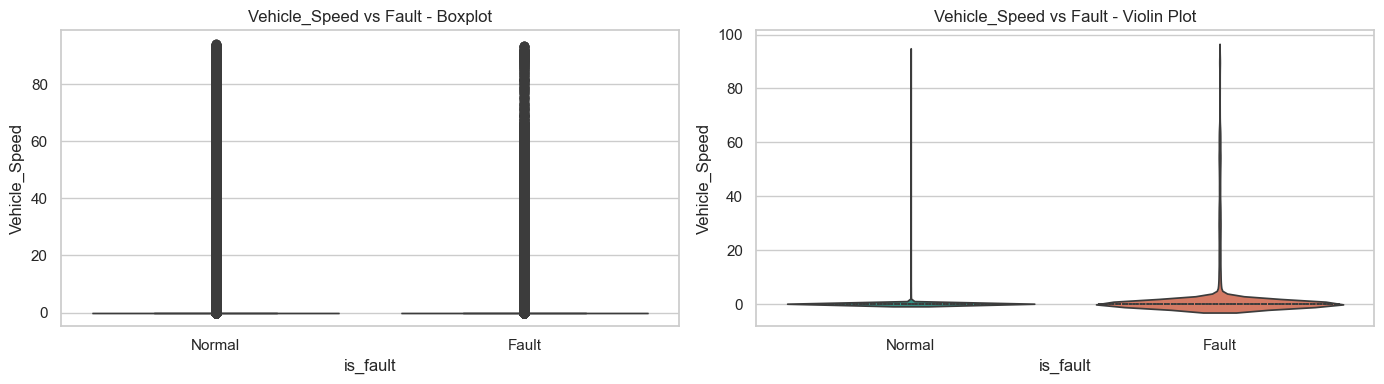

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

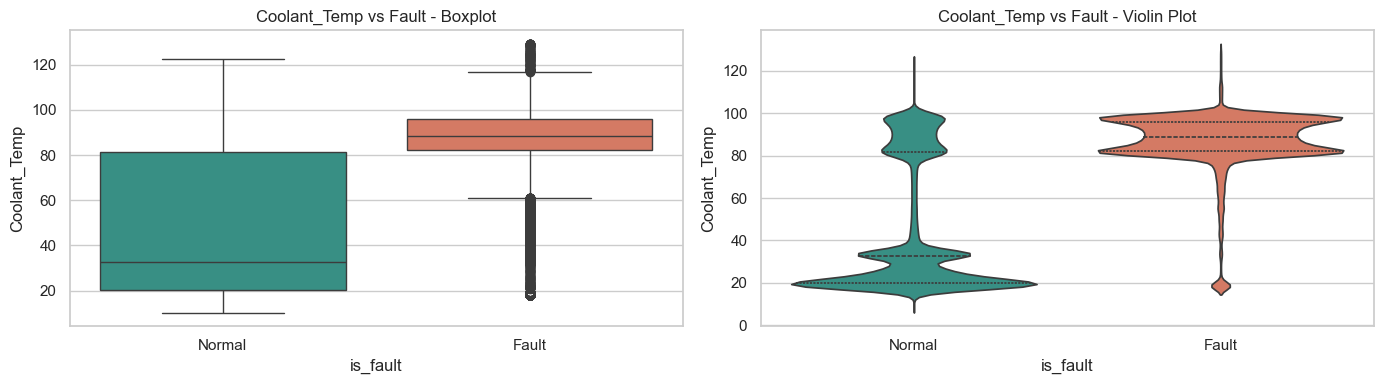

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

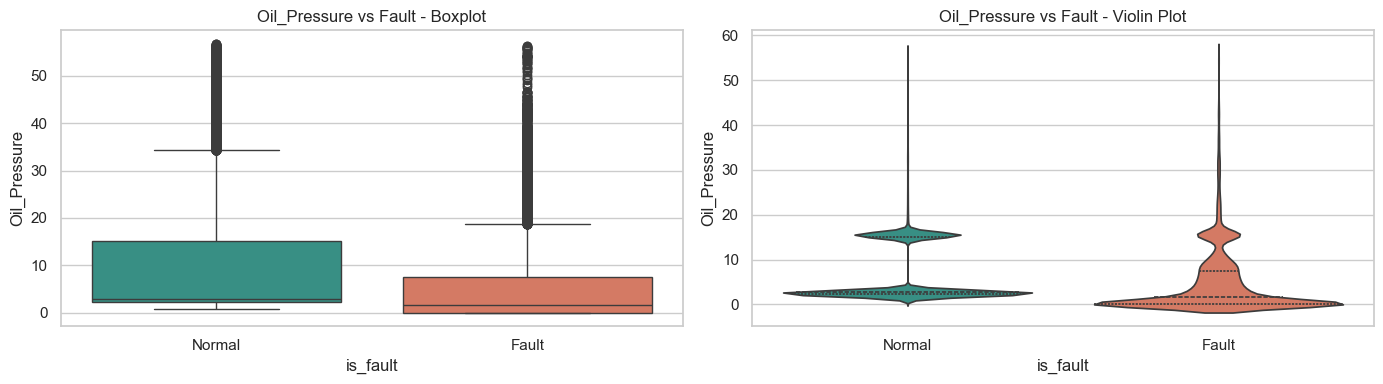

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

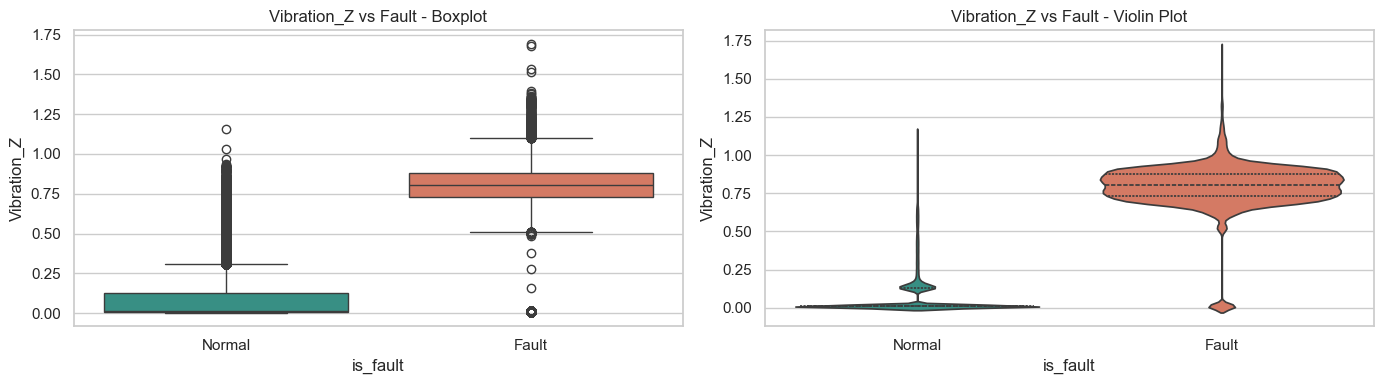

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

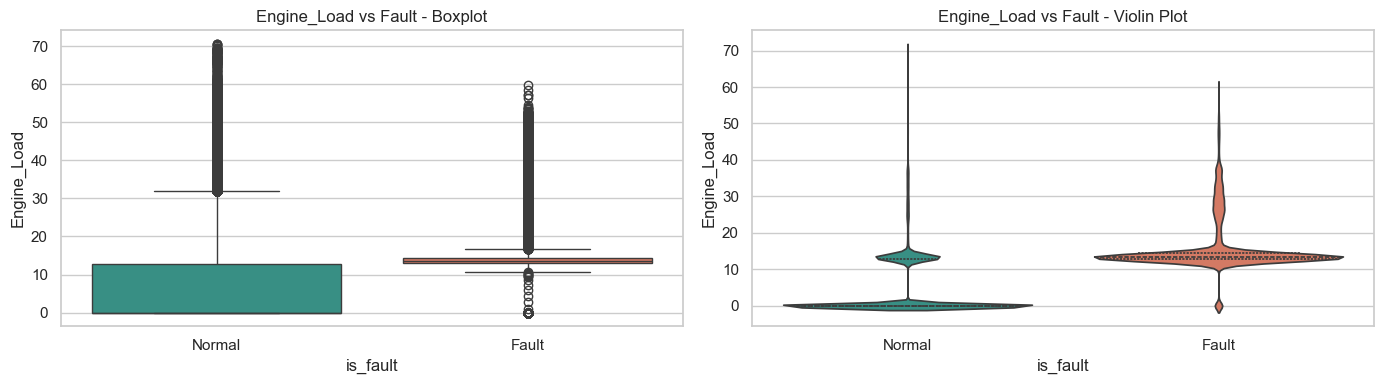

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

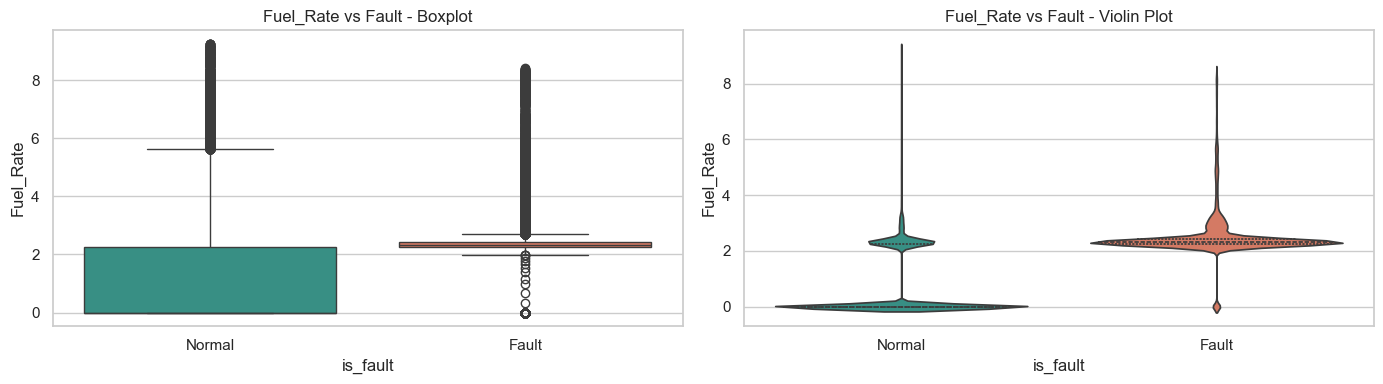

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

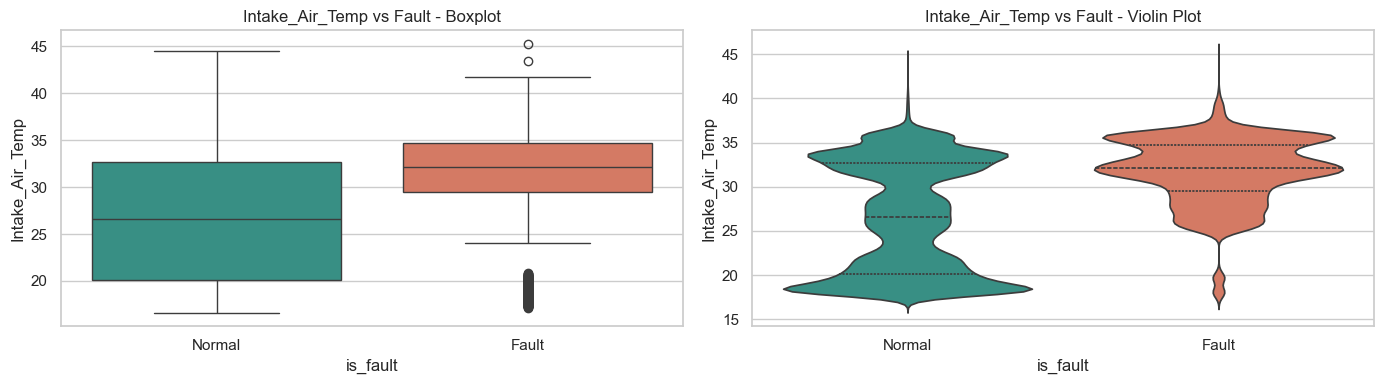

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

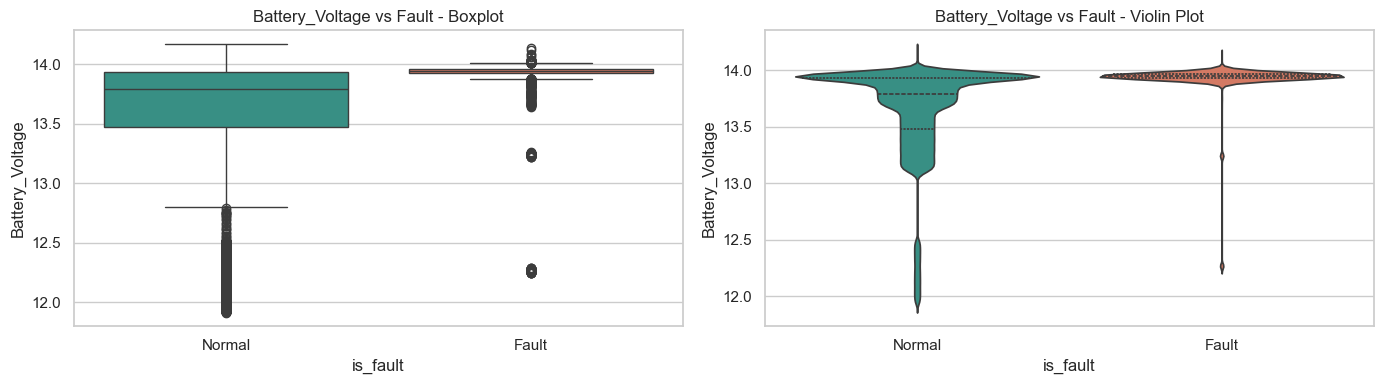

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

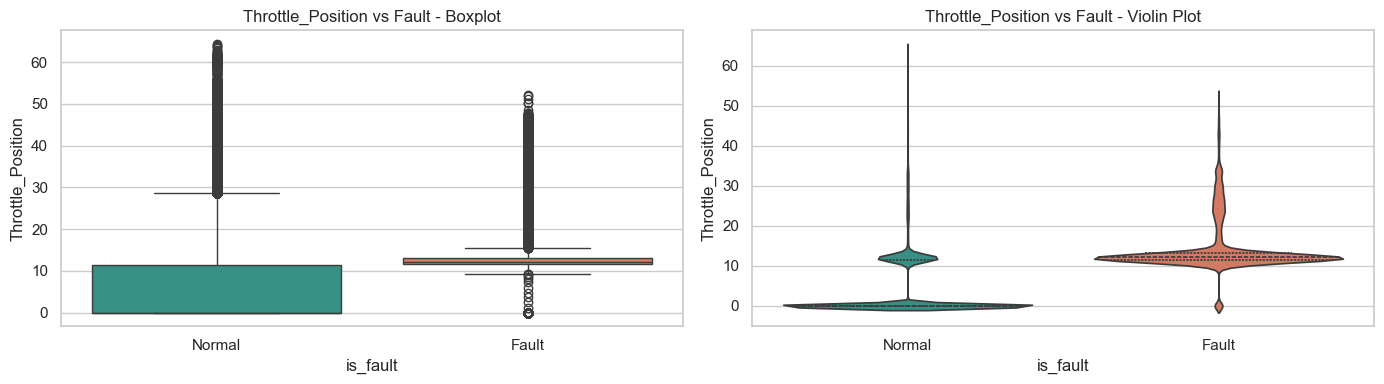

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

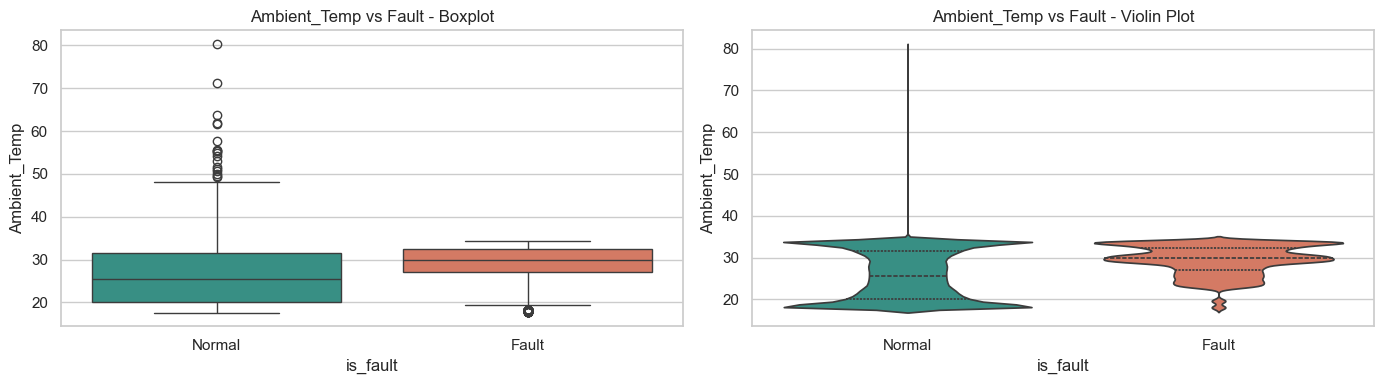

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

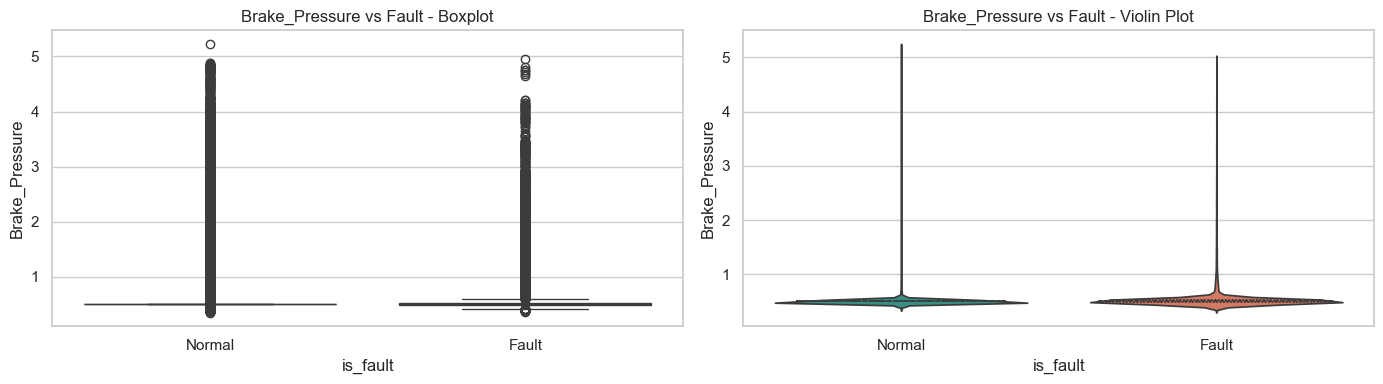

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

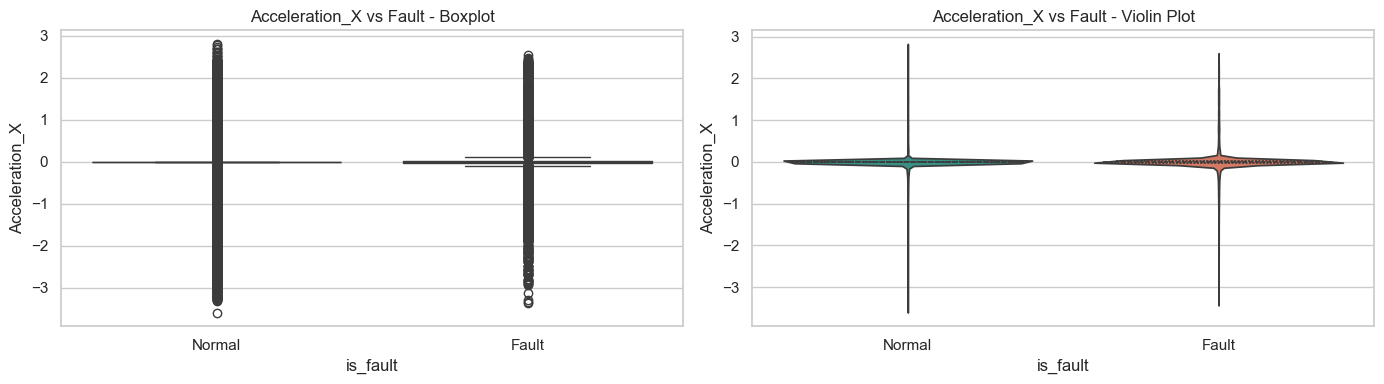

C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(target_labels)
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
C:\Users\jawad\AppData\Local\Temp\ipykernel_15292\433027133.py:7: UserWarning: set_ticklabels() 

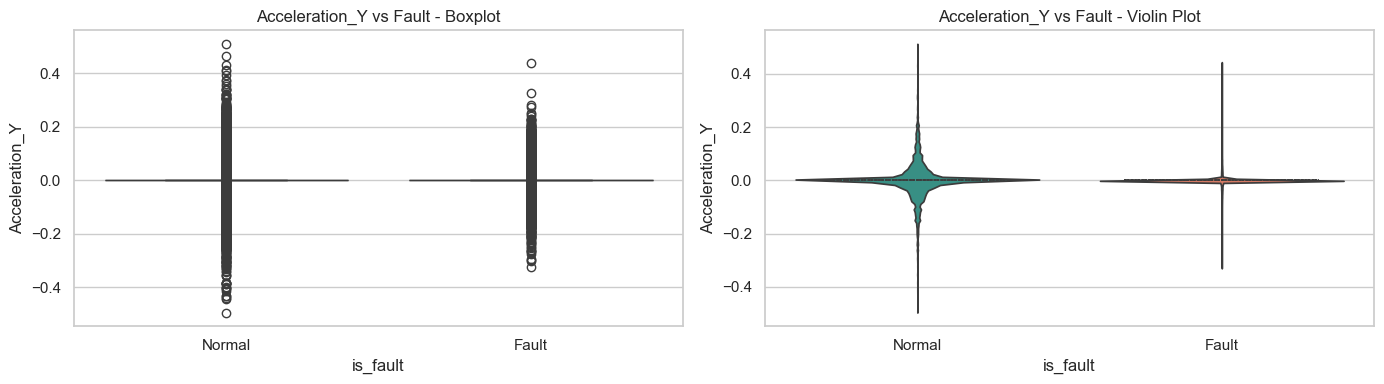

In [19]:
for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.boxplot(data=df, x=target, y=col, palette=target_colors, ax=axes[0])
    axes[0].set_xticklabels(target_labels)
    axes[0].set_title(f'{col} vs Fault - Boxplot')
    sns.violinplot(data=df, x=target, y=col, palette=target_colors, inner='quartile', ax=axes[1])
    axes[1].set_xticklabels(target_labels)
    axes[1].set_title(f'{col} vs Fault - Violin Plot')
    plt.tight_layout()
    plt.show()


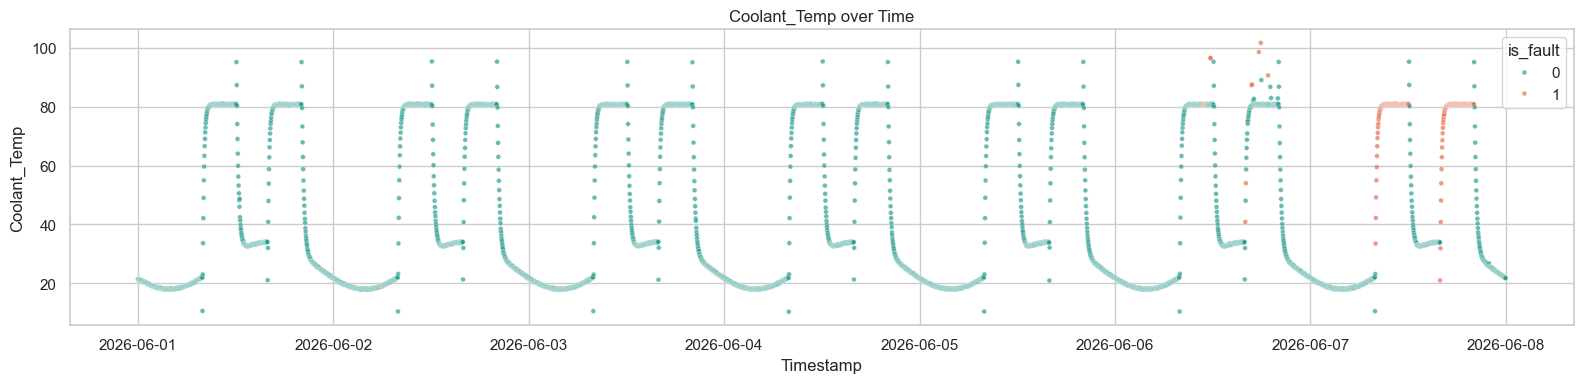

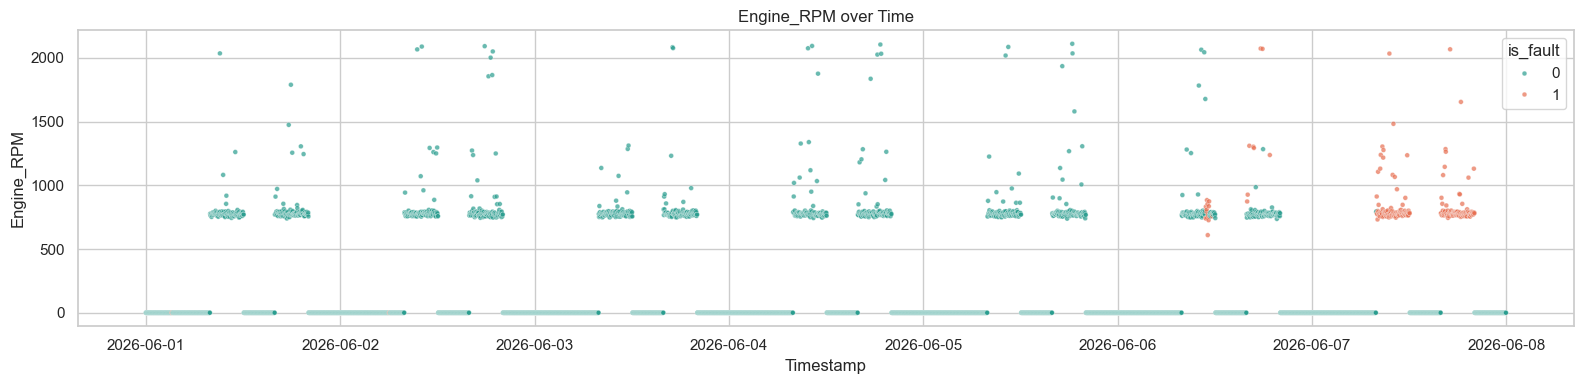

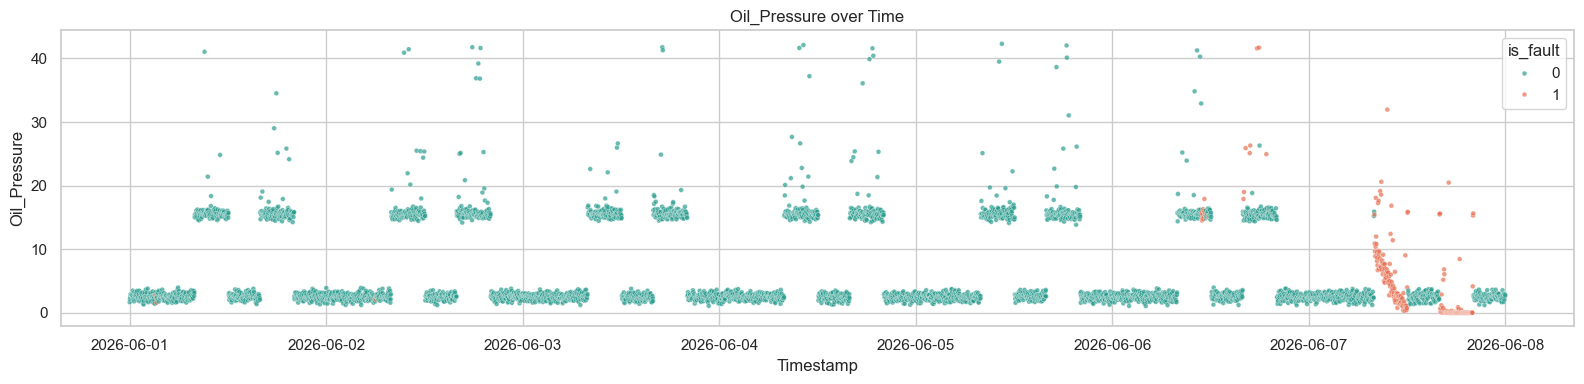

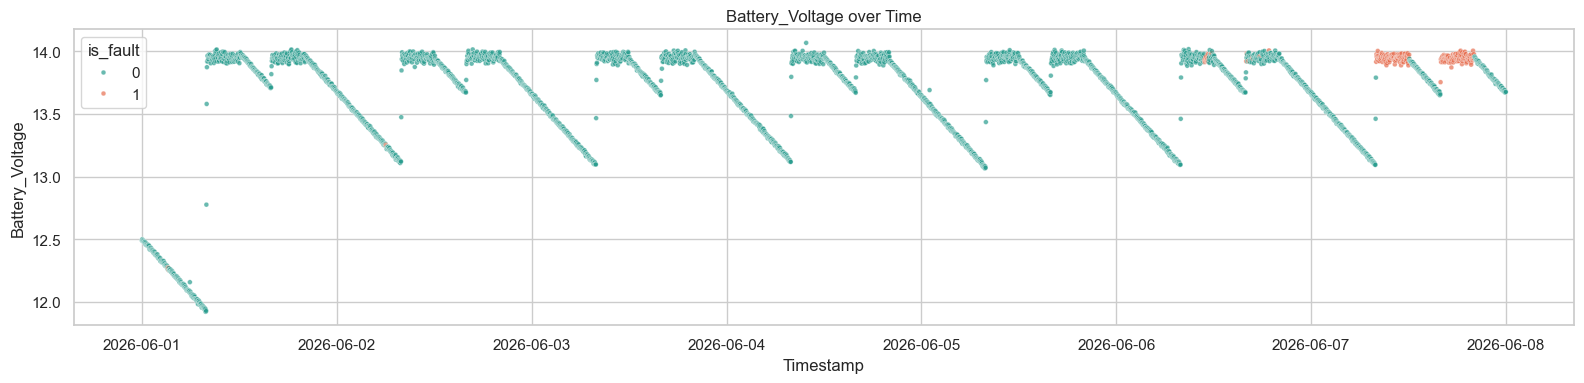

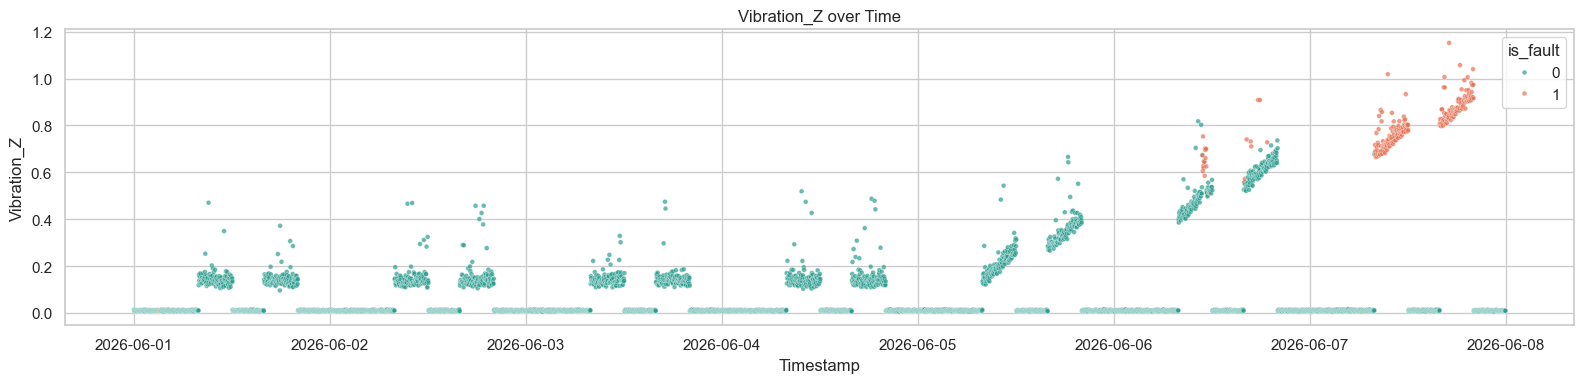

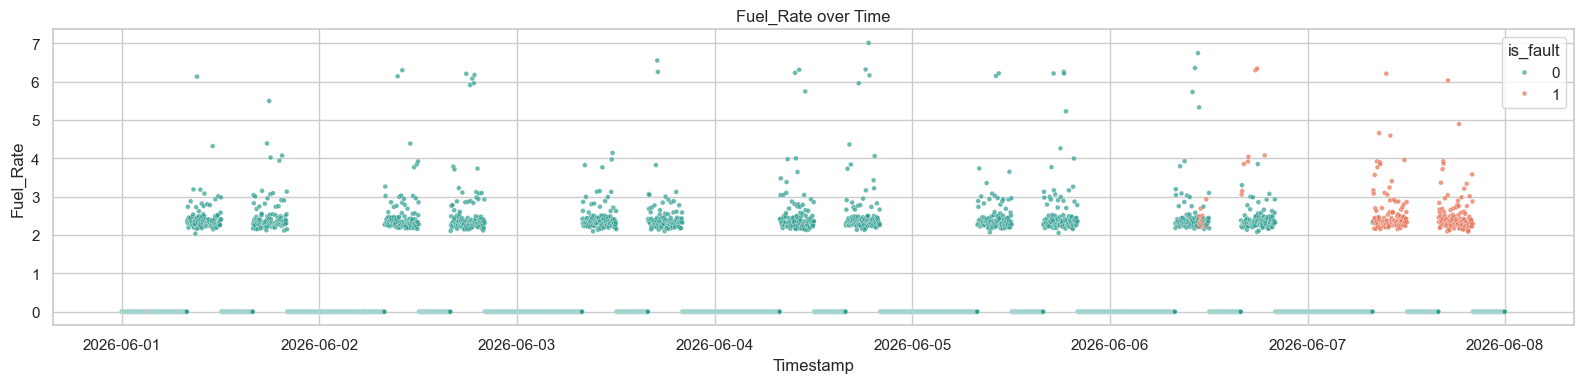

In [20]:
if time_col:
    ts_df = df.dropna(subset=[time_col]).sort_values(time_col).copy()
    sample_step = max(len(ts_df) // 5000, 1)
    ts_plot = ts_df.iloc[::sample_step].copy()
    for col in main_sensors:
        fig, ax = plt.subplots(figsize=(16, 4))
        sns.scatterplot(data=ts_plot, x=time_col, y=col, hue=target, palette={0: '#2a9d8f', 1: '#e76f51'}, s=12, alpha=0.7, ax=ax)
        ax.set_title(f'{col} over Time')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel(col)
        plt.tight_layout()
        plt.show()

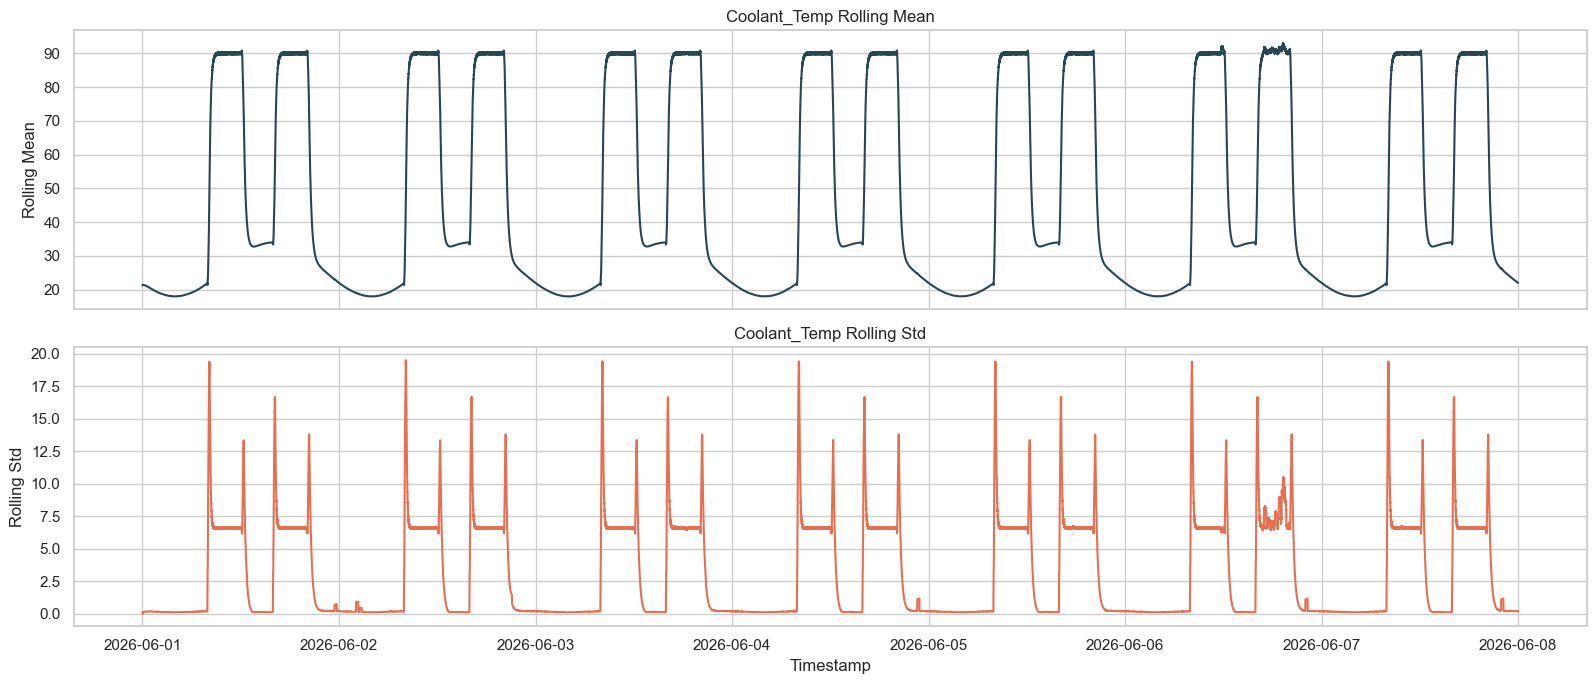

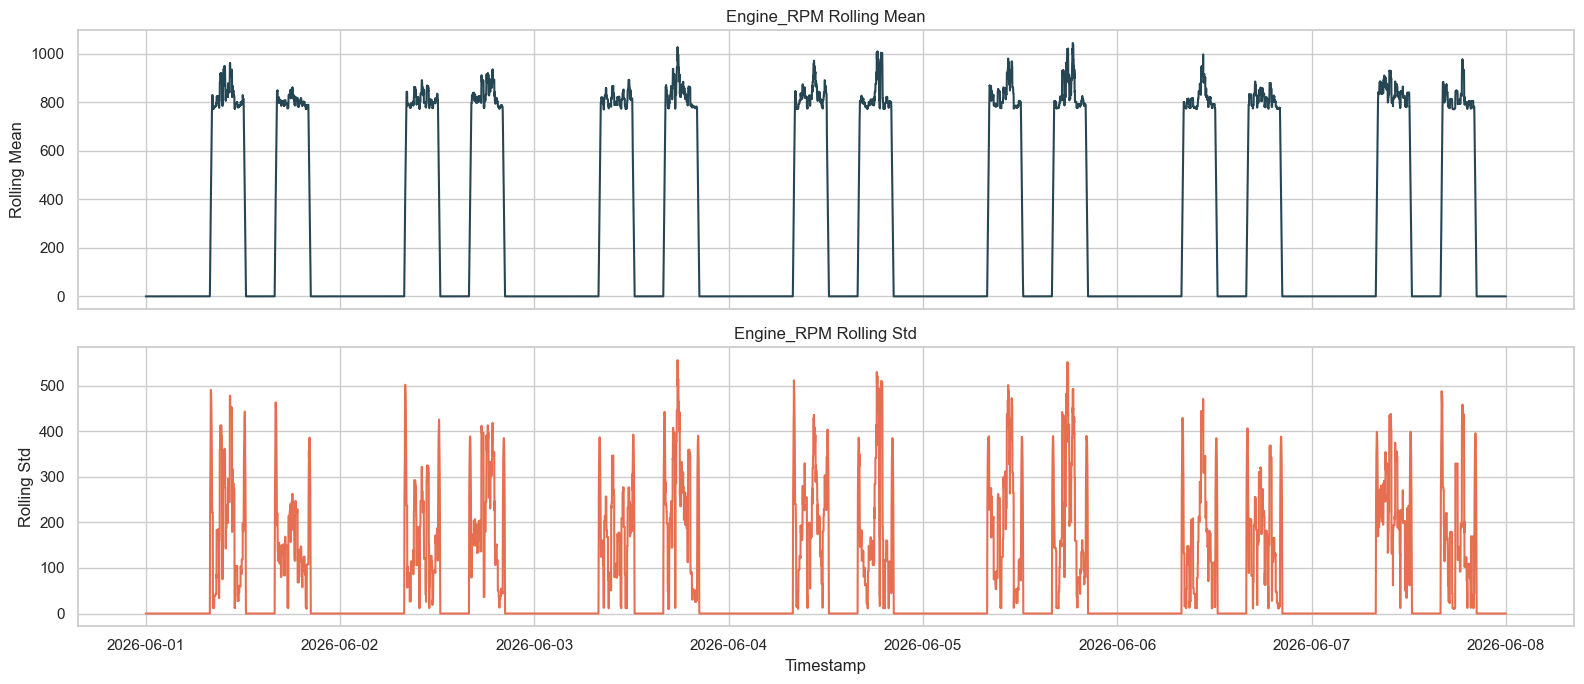

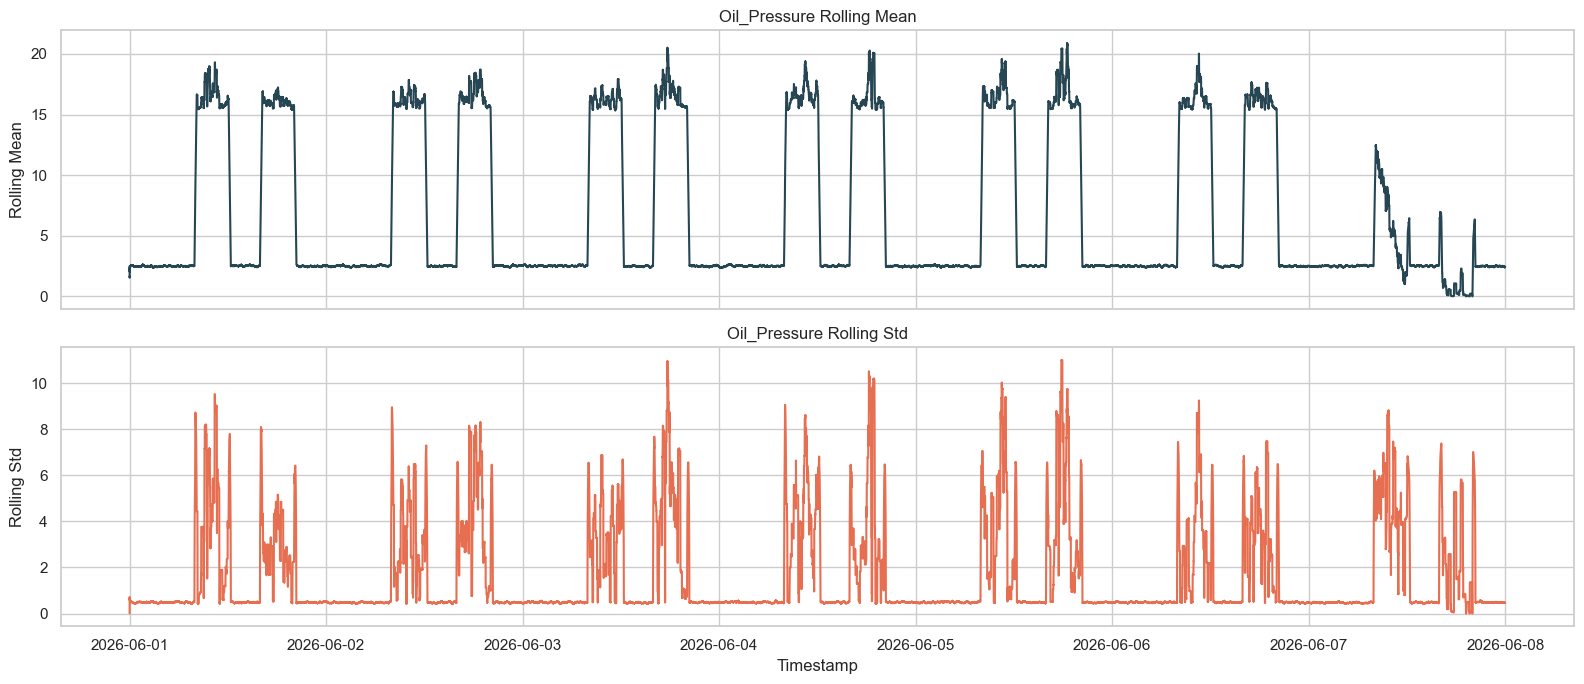

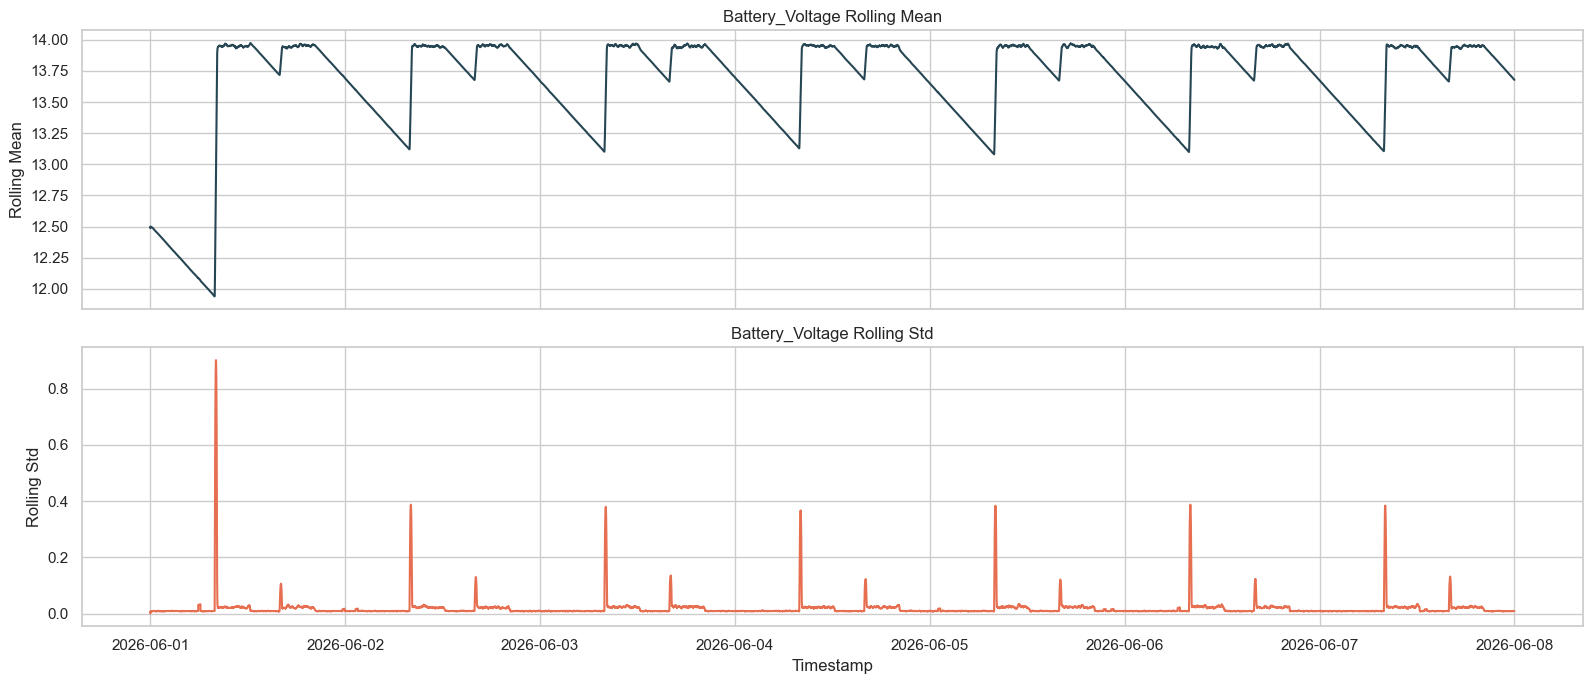

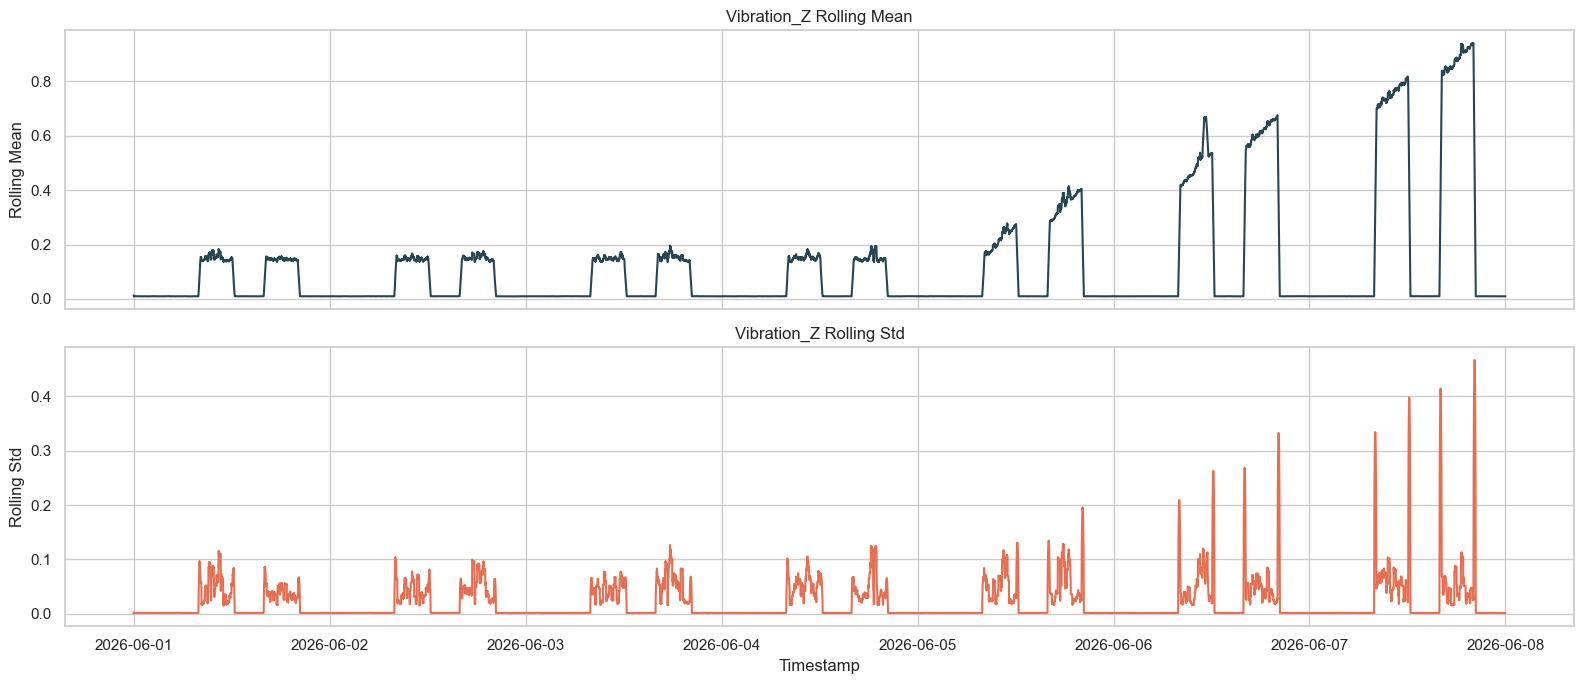

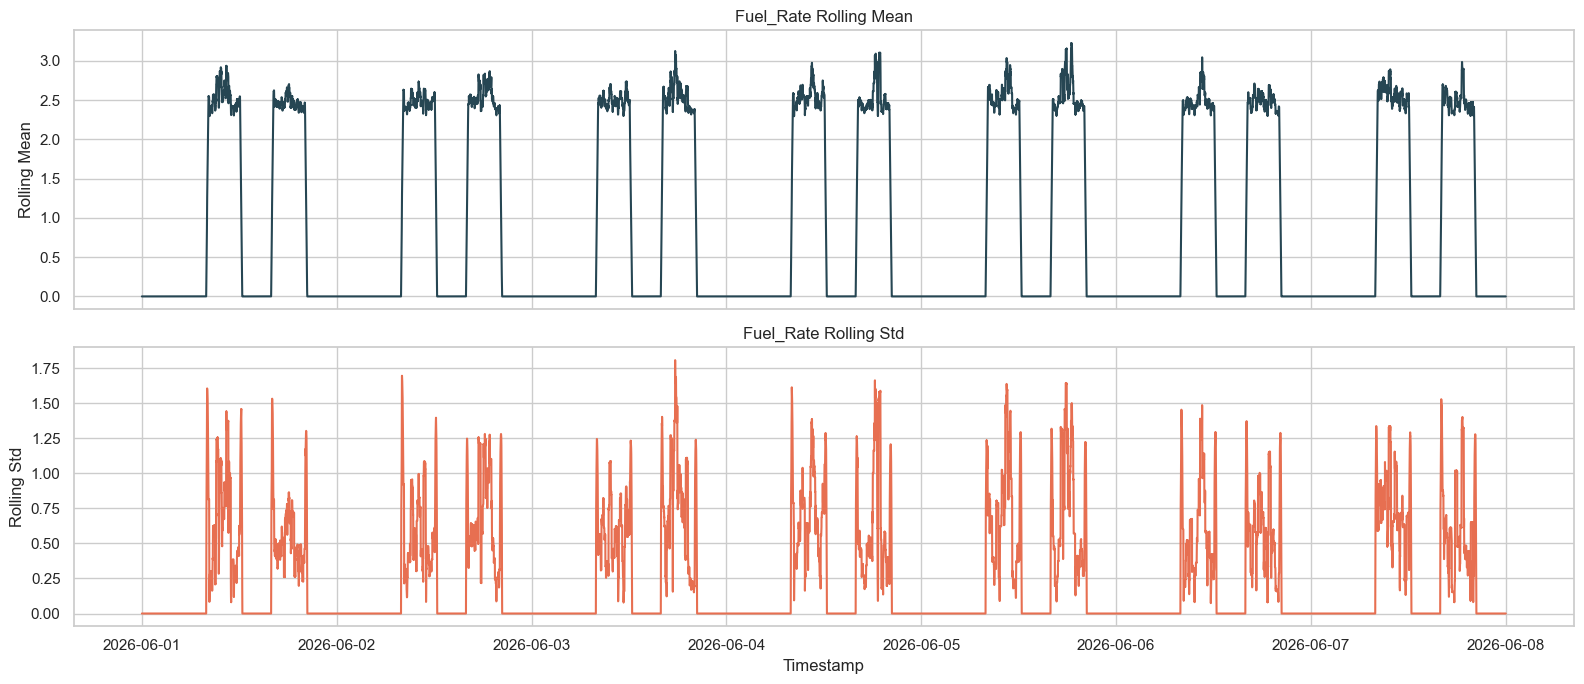

In [21]:
if time_col:
    roll_df = df.dropna(subset=[time_col]).sort_values(time_col).copy()
    window_size = min(1000, max(50, len(roll_df) // 500))
    for col in main_sensors:
        fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
        rolling_mean = roll_df[col].rolling(window=window_size, min_periods=1).mean()
        rolling_std = roll_df[col].rolling(window=window_size, min_periods=1).std()
        axes[0].plot(roll_df[time_col], rolling_mean, color='#264653')
        axes[0].set_title(f'{col} Rolling Mean')
        axes[0].set_ylabel('Rolling Mean')
        axes[1].plot(roll_df[time_col], rolling_std, color='#e76f51')
        axes[1].set_title(f'{col} Rolling Std')
        axes[1].set_ylabel('Rolling Std')
        axes[1].set_xlabel('Timestamp')
        plt.tight_layout()
        plt.show()





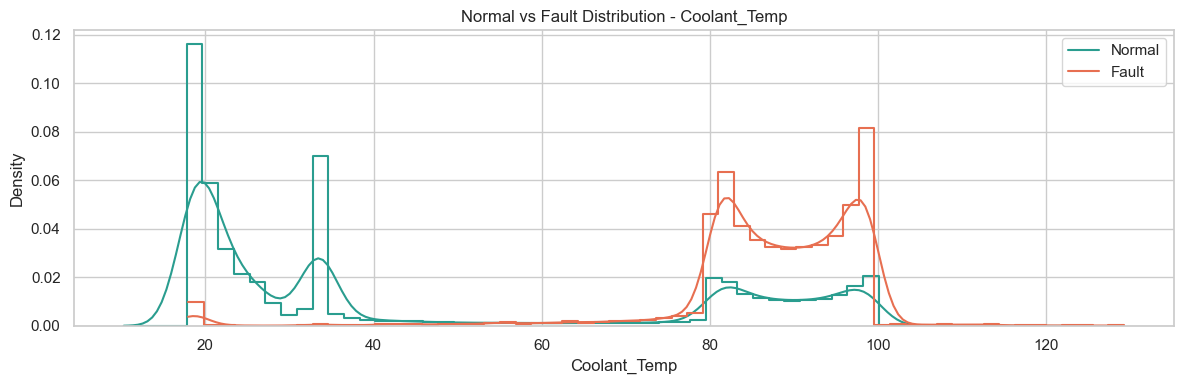

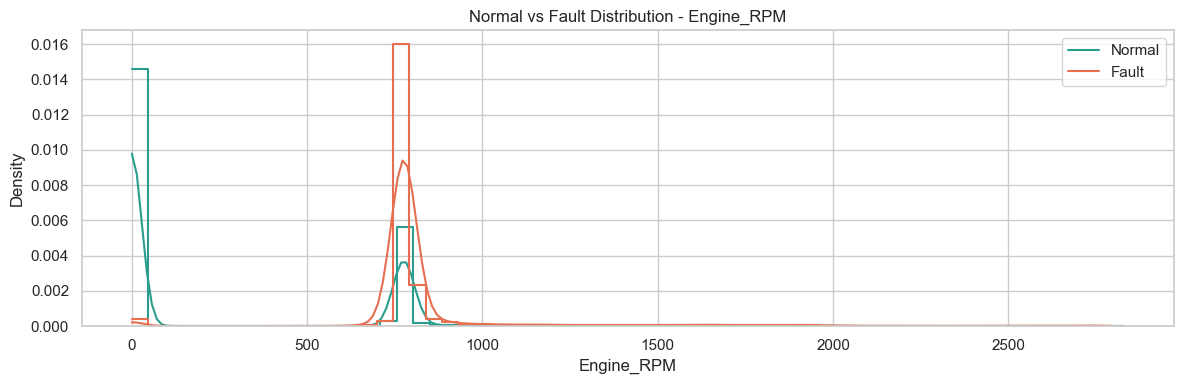

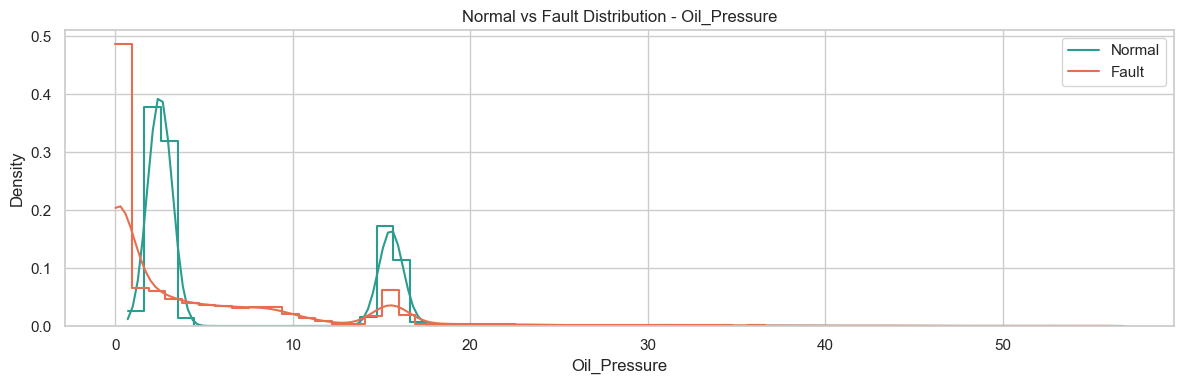

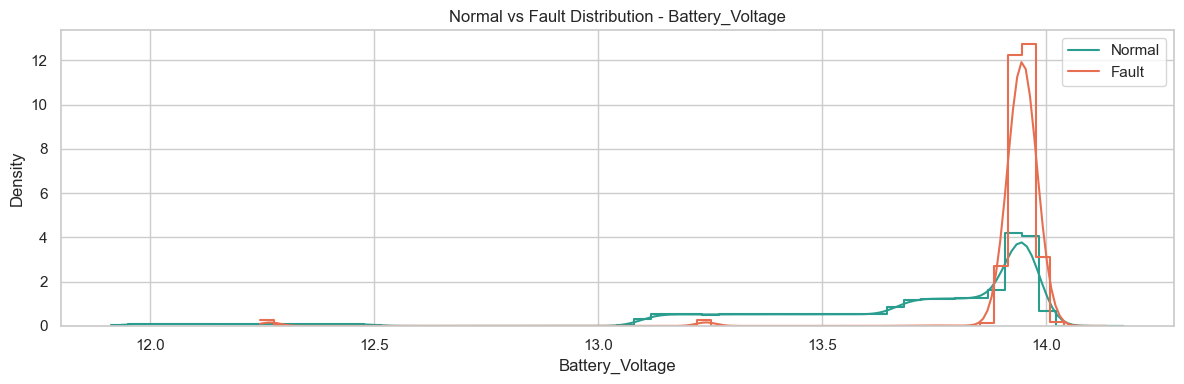

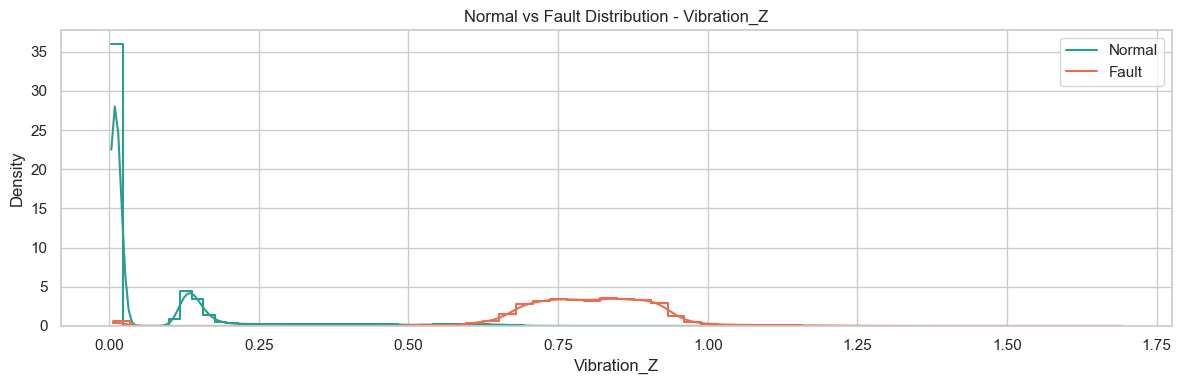

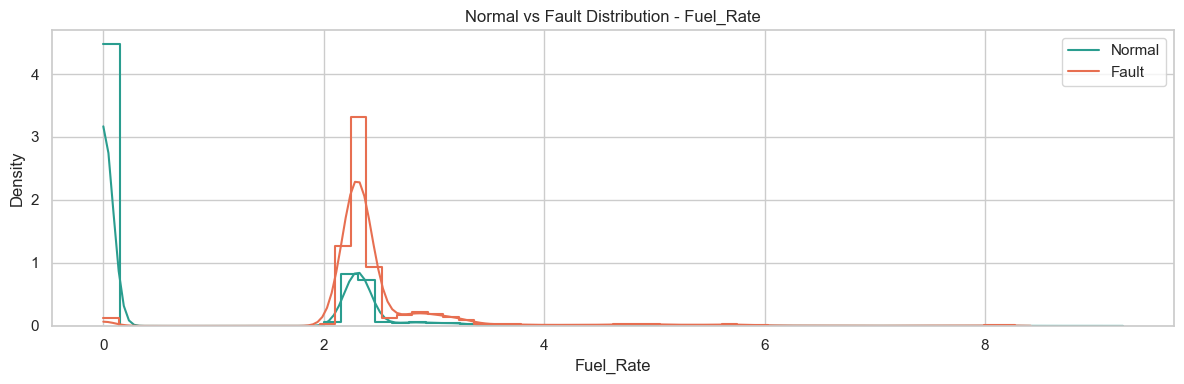

In [22]:
for col in main_sensors:
    normal_values = df.loc[df[target] == 0, col].dropna()
    fault_values = df.loc[df[target] == 1, col].dropna()
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.histplot(normal_values, bins=60, stat='density', kde=True, color='#2a9d8f', label='Normal', ax=ax, element='step', fill=False)
    sns.histplot(fault_values, bins=60, stat='density', kde=True, color='#e76f51', label='Fault', ax=ax, element='step', fill=False)
    ax.set_title(f'Normal vs Fault Distribution - {col}')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [23]:
test_rows = []
for col in feature_cols:
    normal_values = df.loc[df[target] == 0, col].dropna()
    fault_values = df.loc[df[target] == 1, col].dropna()
    p_value = ttest_ind(normal_values, fault_values, equal_var=False, nan_policy='omit').pvalue
    test_rows.append([col, p_value, p_value < 0.05])
tests_df = pd.DataFrame(test_rows, columns=['Feature', 'p-value', 'Significant?']).sort_values('p-value')
display(tests_df)

,Feature,p-value,Significant?
0,Engine_RPM,0.0000,True
1,Vehicle_Speed,0.0000,True
2,Coolant_Temp,0.0000,True
3,Oil_Pressure,0.0000,True
4,Vibration_Z,0.0000,True
5,Engine_Load,0.0000,True
6,Fuel_Rate,0.0000,True
7,Intake_Air_Temp,0.0000,True
8,Battery_Voltage,0.0000,True
9,Throttle_Position,0.0000,True


In [24]:
display(Markdown(''))
lowest_p_feature = tests_df.iloc[0]['Feature'] if not tests_df.empty else 'N/A'
highest_outlier_feature = outlier_df.iloc[0]['Feature'] if not outlier_df.empty else 'N/A'
lowest_variability_feature = df[main_sensors].std().sort_values().index[0] if main_sensors else 'N/A'
highest_variability_feature = df[main_sensors].std().sort_values(ascending=False).index[0] if main_sensors else 'N/A'
insights = [
    f'Faults account for {fault_rate:.2f}% of observations.',
    f'{highest_variability_feature} shows the highest variability among the key sensors.',
    f'{lowest_variability_feature} is the most stable sensor among the key sensors.',
    f'{highest_outlier_feature} has the highest outlier percentage using the IQR rule.',
    f'{lowest_p_feature} shows the strongest statistical difference between Normal and Fault groups.'
]
display(Markdown('\n'.join([f'- {item}' for item in insights])))


- Faults account for 5.46% of observations.
- Engine_RPM shows the highest variability among the key sensors.
- Vibration_Z is the most stable sensor among the key sensors.
- Acceleration_X has the highest outlier percentage using the IQR rule.
- Engine_RPM shows the strongest statistical difference between Normal and Fault groups.

In [25]:
cleaned_dataset = df.copy()
dashboard_columns = [c for c in ['Timestamp', 'is_fault', 'Fault_Type', 'Fault_Label'] + main_sensors if c in df.columns]
dashboard_dataset = df[dashboard_columns].copy()
cleaned_dataset.to_csv('Cleaned_Dataset.csv', index=False)
dashboard_dataset.to_csv('Dashboard_Dataset.csv', index=False)
display(Markdown('Export completed: Cleaned_Dataset.csv and Dashboard_Dataset.csv are ready for downstream tools.'))

Export completed: Cleaned_Dataset.csv and Dashboard_Dataset.csv are ready for downstream tools.